# Q4 — Classificação do risco de não atingir a meta

Este notebook responde à pergunta:

> **Q4. Como prever municípios que podem não atingir metas futuras?**

A abordagem é de **classificação binária supervisionada**:

- `risco_nao_atingir_meta = 1` quando `taxa_realizada < meta`;
- `risco_nao_atingir_meta = 0` quando `taxa_realizada >= meta`.

A unidade de análise permanece **(município, ano)**.

A diferença conceitual em relação à Q2 é importante:

- **Q2** identifica vulnerabilidade educacional absoluta;
- **Q4** estima o risco de o município ficar abaixo de uma **meta específica já conhecida antes do resultado**.

Por isso, `meta` pode ser utilizada como feature em Q4. Também será avaliada a variável `esforco_pactuado`, definida como a diferença entre a meta atual e a taxa observada no período anterior:

```python
esforco_pactuado = meta - taxa_lag1
```

A estratégia temporal será:

- **2024 = desenvolvimento**;
- **2025 = teste temporal final**.

Neste primeiro trecho, **nenhum modelo será treinado**. Antes da modelagem, precisamos confirmar:

1. se o target está consistente com a regra pactuada;
2. quais features podem ser utilizadas sem vazamento de informação;
3. se `meta` e `esforco_pactuado` estão consistentes;
4. como o target se distribui em 2024 e 2025;
5. quão estável é a condição de cumprimento da meta entre os dois anos.

As próximas decisões de modelagem serão tomadas somente depois de observar esses resultados.

## 1. Ambiente e leitura da base

A entrada é a base município-ano já preparada anteriormente:

`/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet`

O ano de **2024** será usado para desenvolvimento dos modelos.

O ano de **2025** será preservado como teste temporal final. Ele pode aparecer em auditorias descritivas do target, mas não participa da seleção de modelo, features, preprocessing ou threshold.

Antes das análises de Q4, são aplicadas duas regras de elegibilidade de forma única e centralizada:

- remover registros com `meta == 0`;
- remover registros com `taxa_realizada == 0`, tratado como valor inválido neste projeto.

A partir desse ponto, auditorias, distribuições, estabilidade temporal e modelagem utilizam a mesma população elegível em `dados_q4`.


In [53]:
# Caso o computador tenho poder de processamento suficiente para a tarefa, troque o valor da variável AMBIENTE_COLAB para False.
AMBIENTE_COLAB = True

In [54]:
if AMBIENTE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    from src.config import PROCESSED_DATA_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

TARGET_Q4 = 'risco_nao_atingir_meta'
COLUNA_TAXA = 'taxa_realizada'
COLUNA_META = 'meta'

if AMBIENTE_COLAB:
    DIR_MODELAGEM = Path(
        '/content/drive/Othercomputers/@lua2026/01_projects/2026_FIAP/desafios/postech-challenge-3/data/processed/modelagem/dados_modelagem_municipio_ano_2024_2025.parquet'
    )

else:
    DIR_MODELAGEM = PROCESSED_DATA_DIR / 'modelagem'


if not DIR_MODELAGEM.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {DIR_MODELAGEM}\n'
        'Confirme se o Google Drive foi montado e se a base está no caminho esperado.'
    )

dados = pd.read_parquet(DIR_MODELAGEM)

colunas_obrigatorias_q4 = [TARGET_Q4, COLUNA_TAXA, COLUNA_META]
faltantes_q4 = [c for c in colunas_obrigatorias_q4 if c not in dados.columns]
if faltantes_q4:
    raise KeyError(f'Colunas obrigatórias ausentes para Q4: {faltantes_q4}')

# Regra de elegibilidade aplicada antes de qualquer análise descritiva de Q4:
# - meta == 0 não representa um referencial útil para o problema;
# - taxa_realizada == 0 é tratada como valor inválido para este projeto.
mascara_meta_zero = dados[COLUNA_META].eq(0)
mascara_taxa_zero = dados[COLUNA_TAXA].eq(0)
mascara_invalida_q4 = mascara_meta_zero | mascara_taxa_zero

resumo_filtros_q4 = (
    pd.DataFrame({
        'ano': dados['ano'],
        'meta_zero': mascara_meta_zero,
        'taxa_realizada_zero': mascara_taxa_zero,
        'removido_q4': mascara_invalida_q4,
    })
    .groupby('ano')[['meta_zero', 'taxa_realizada_zero', 'removido_q4']]
    .sum()
    .astype(int)
)

dados_q4 = dados.loc[~mascara_invalida_q4].copy()

print(f'Dimensões da base original: {dados.shape[0]:,} linhas × {dados.shape[1]:,} colunas')
print(f'Registros elegíveis para Q4 após os filtros: {len(dados_q4):,}')
display(resumo_filtros_q4)
display(dados_q4.head())


Dimensões da base original: 11,073 linhas × 50 colunas
Registros elegíveis para Q4 após os filtros: 11,007


,meta_zero,taxa_realizada_zero,removido_q4
ano,,,
2024,16,1,17
2025,46,3,49


,ano,id_uf,id_municipio,nome_municipio,alunos,taxa_realizada,proficiencia_media,escolas,pct_rede_municipal,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atlas_idhm_longevidade,ctx_atlas_taxa_analfabetismo_11a14,ctx_atlas_taxa_analfabetismo_15a17,ctx_atlas_taxa_analfabetismo_15mais,ctx_atlas_taxa_frequencia_0a3,ctx_atlas_expectativa_anos_estudo,ctx_atlas_indice_gini,ctx_atlas_taxa_trabalho_infantil_10a14,ctx_atlas_taxa_maes_10a14,ctx_atlas_taxa_maes_chefes_familia,ctx_atlas_taxa_fora_escola_4a5,ctx_atlas_taxa_fora_escola_6a14,ctx_atlas_taxa_frequencia_liquida_fundamental,ctx_atlas_percentual_domicilios_agua,ctx_atlas_percentual_domicilios_energia,ctx_atlas_taxa_densidade_domiciliar,ctx_fundeb_nse_uf,populacao,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_media,taxa_lag1,proficiencia_lag1,participacao_lag1,meta,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,risco_educacional,risco_nao_atingir_meta,distancia_ate_a_meta,esforco_pactuado
0,2024,11,1100015,Alta Floresta D'Oeste,275,68.000,752.593,8,100.000,18.800,14.800,20.900,22.100,23.400,21.300,23.400,21.000,20.600,0.763,1.220,1.520,11.990,4.890,8.670,0.580,9.080,0.000,14.510,60.820,4.320,92.880,93.690,93.980,22.580,49.335,"22,853.000","7,067.127",0.397,0.005,"1,210.600",64.550,758.330,89.370,67.000,759.436,88.100,0.000,0.000,1.000,2.450
1,2024,11,1100023,Ariquemes,1066,65.854,748.307,18,100.000,23.500,20.500,25.200,25.000,24.900,23.200,25.800,26.000,25.500,0.806,1.550,1.090,7.900,9.890,9.180,0.530,7.890,0.000,18.070,44.660,2.790,91.310,98.540,98.580,27.150,49.335,"108,573.000","4,426.571",0.133,0.020,"1,458.570",62.300,757.100,89.790,65.000,759.436,88.100,0.000,0.000,0.854,2.700
2,2024,11,1100031,Cabixi,75,76.000,759.857,2,100.000,19.400,36.500,15.600,14.300,13.400,14.000,17.400,14.800,12.200,0.757,0.620,1.060,13.630,12.490,10.090,0.510,12.160,1.120,7.030,33.080,1.970,92.810,95.490,96.360,19.930,49.335,"5,690.000","1,314.352",0.468,0.016,"1,323.790",69.100,767.876,90.480,71.000,759.436,88.100,0.000,0.000,5.000,1.900
3,2024,11,1100049,Cacoal,951,66.351,747.937,19,83.701,17.400,17.700,17.300,20.721,21.593,22.260,21.662,17.402,19.280,0.821,1.010,0.800,8.290,11.380,9.740,0.570,11.800,0.680,12.800,37.590,2.390,93.020,97.960,98.890,20.500,49.335,"97,637.000","3,793.000",0.172,0.672,"1,625.880",62.510,755.564,84.440,65.000,759.436,88.100,0.000,0.000,1.351,2.490
4,2024,11,1100056,Cerejeiras,244,66.803,749.646,4,100.000,17.700,14.800,19.900,22.400,22.800,24.000,21.600,22.100,21.000,0.799,1.140,0.750,10.290,13.450,10.220,0.500,10.500,0.000,25.880,38.730,1.460,93.470,97.530,98.850,16.660,49.335,"16,975.000","2,783.300",0.112,0.580,"1,554.330",58.530,746.463,92.120,62.000,759.436,88.100,0.000,0.000,4.803,3.470


In [56]:
mapa_ufs = {
    11: ('RO', 'Norte'),
    12: ('AC', 'Norte'),
    13: ('AM', 'Norte'),
    14: ('RR', 'Norte'),
    15: ('PA', 'Norte'),
    16: ('AP', 'Norte'),
    17: ('TO', 'Norte'),
    21: ('MA', 'Nordeste'),
    22: ('PI', 'Nordeste'),
    23: ('CE', 'Nordeste'),
    24: ('RN', 'Nordeste'),
    25: ('PB', 'Nordeste'),
    26: ('PE', 'Nordeste'),
    27: ('AL', 'Nordeste'),
    28: ('SE', 'Nordeste'),
    29: ('BA', 'Nordeste'),
    31: ('MG', 'Sudeste'),
    32: ('ES', 'Sudeste'),
    33: ('RJ', 'Sudeste'),
    35: ('SP', 'Sudeste'),
    41: ('PR', 'Sul'),
    42: ('SC', 'Sul'),
    43: ('RS', 'Sul'),
    50: ('MS', 'Centro-Oeste'),
    51: ('MT', 'Centro-Oeste'),
    52: ('GO', 'Centro-Oeste'),
    53: ('DF', 'Centro-Oeste'),
}

def adicionar_uf_regiao(df, coluna_id_uf='id_uf'):
    df = df.copy()

    if coluna_id_uf not in df.columns:
        return df

    ids_uf = pd.to_numeric(
        df[coluna_id_uf],
        errors='coerce',
    ).astype('Int64')

    df['uf'] = ids_uf.map(
        lambda x: mapa_ufs.get(int(x), (pd.NA, pd.NA))[0]
        if pd.notna(x) else pd.NA
    )
    df['regiao'] = ids_uf.map(
        lambda x: mapa_ufs.get(int(x), (pd.NA, pd.NA))[1]
        if pd.notna(x) else pd.NA
    )

    return df

print('Mapa de UFs preparado para enriquecer tabelas de auditoria e identificação.')


Mapa de UFs preparado para enriquecer tabelas de auditoria e identificação.


## 2. Auditoria mínima da unidade de análise

Antes de analisar o target, validamos apenas o necessário para este notebook:

- presença de 2024 e 2025;
- presença das chaves `ano`, `id_uf` e `id_municipio`;
- ausência de duplicidade em `(id_municipio, ano)`;
- quantidade de municípios por ano.

Essa checagem evita interpretar registros duplicados como unidades diferentes.

In [57]:
COLUNAS_CHAVE = ['ano', 'id_uf', 'id_municipio']
ANOS_ANALISE = [2024, 2025]

faltantes_chave = [c for c in COLUNAS_CHAVE if c not in dados_q4.columns]
if faltantes_chave:
    raise KeyError(f'Colunas-chave ausentes: {faltantes_chave}')

anos_encontrados = sorted(dados_q4['ano'].dropna().unique().tolist())
print('Anos encontrados:', anos_encontrados)

for ano in ANOS_ANALISE:
    if ano not in anos_encontrados:
        raise ValueError(f'O ano {ano} não está presente na base.')

duplicados = dados_q4.duplicated(subset=['id_municipio', 'ano'], keep=False)

print(f'Duplicidades em (id_municipio, ano): {duplicados.sum():,}')

if duplicados.any():
    duplicados_exibicao = adicionar_uf_regiao(
        dados_q4.loc[duplicados, COLUNAS_CHAVE]
    )

    colunas_duplicados = [
        c for c in [
            'ano',
            'id_uf',
            'uf',
            'regiao',
            'id_municipio',
        ]
        if c in duplicados_exibicao.columns
    ]

    display(
        duplicados_exibicao[colunas_duplicados]
        .sort_values(['id_municipio', 'ano'])
        .head(20)
    )
    raise ValueError(
        'Foram encontradas duplicidades na unidade município-ano. '
        'Corrija a base antes de continuar.'
    )

municipios_por_ano = (
    dados_q4.groupby('ano')
    .size()
    .rename('municipios')
    .to_frame()
)

display(municipios_por_ano.loc[ANOS_ANALISE])

Anos encontrados: [2024, 2025]
Duplicidades em (id_municipio, ano): 0


,municipios
ano,
2024,5500
2025,5507


## 3. Validação da definição do target de Q4

O target já existe na base como `risco_nao_atingir_meta`.

A regra pactuada é:

```python
risco_nao_atingir_meta = 1  # taxa_realizada < meta
risco_nao_atingir_meta = 0  # taxa_realizada >= meta
```

Neste notebook **não redefinimos o target**. Apenas verificamos se o valor salvo na base respeita essa regra.

`taxa_realizada` será utilizada nesta seção **somente para auditoria**. Ela não poderá entrar no conjunto de features porque determina diretamente o target que queremos prever.

In [58]:
colunas_obrigatorias = [TARGET_Q4, COLUNA_TAXA, COLUNA_META]
faltantes = [c for c in colunas_obrigatorias if c not in dados_q4.columns]

if faltantes:
    raise KeyError(f'Colunas obrigatórias ausentes para Q4: {faltantes}')

# Primeiro verificamos todos os valores não nulos encontrados no target.
target_nao_nulo = pd.to_numeric(
    dados_q4.loc[dados_q4[TARGET_Q4].notna(), TARGET_Q4],
    errors='raise'
)

valores_target = sorted(target_nao_nulo.unique().tolist())
print('Valores observados no target:', valores_target)

if not set(valores_target).issubset({0, 1}):
    raise ValueError(
        f'O target deveria ser binário (0/1), mas foram encontrados: {valores_target}'
    )

# A regra só pode ser auditada onde target, taxa realizada e meta estão disponíveis.
base_validacao_target = dados_q4.loc[
    dados_q4[TARGET_Q4].notna()
    & dados_q4[COLUNA_TAXA].notna()
    & dados_q4[COLUNA_META].notna(),
    ['ano', 'id_uf', 'id_municipio', COLUNA_TAXA, COLUNA_META, TARGET_Q4]
].copy()

base_validacao_target = adicionar_uf_regiao(base_validacao_target)

target_esperado = (
    base_validacao_target[COLUNA_TAXA]
    < base_validacao_target[COLUNA_META]
).astype(int)

target_observado = pd.to_numeric(
    base_validacao_target[TARGET_Q4],
    errors='raise'
).astype(int)

divergencia = target_observado.ne(target_esperado)
n_divergencias = int(divergencia.sum())

print(f'Observações auditadas: {len(base_validacao_target):,}')
print(f'Divergências com a regra taxa_realizada < meta: {n_divergencias:,}')

if n_divergencias > 0:
    divergencias_exibicao = (
        base_validacao_target.loc[divergencia]
        .assign(risco_esperado=target_esperado.loc[divergencia])
    )

    colunas_divergencias = [
        c for c in [
            'ano',
            'id_uf',
            'uf',
            'regiao',
            'id_municipio',
            COLUNA_TAXA,
            COLUNA_META,
            TARGET_Q4,
            'risco_esperado',
        ]
        if c in divergencias_exibicao.columns
    ]

    display(
        divergencias_exibicao[colunas_divergencias]
        .head(20)
    )
    raise ValueError(
        'O target risco_nao_atingir_meta não está consistente com a regra pactuada. '
        'A modelagem deve parar até essa inconsistência ser corrigida.'
    )

print('Target validado: risco_nao_atingir_meta está consistente com taxa_realizada < meta.')

Valores observados no target: [0.0, 1.0]
Observações auditadas: 10,879
Divergências com a regra taxa_realizada < meta: 0
Target validado: risco_nao_atingir_meta está consistente com taxa_realizada < meta.


## 4. Controle preliminar das features

Antes do treinamento, as colunas são separadas pelo **motivo da exclusão**.

### Identificadores

São mantidos apenas para rastreabilidade e para identificar municípios nas análises finais. Não entram no modelo.

### Vazamento de informação

São variáveis que representam o resultado corrente ou são derivadas diretamente dele. Se entrassem em `X`, o modelo teria acesso a informações que não estariam disponíveis no momento real da previsão.

### Exclusões por política do projeto

Algumas variáveis não são necessariamente vazamento, mas já foram excluídas do conjunto estrutural adotado no projeto.

Em Q4, há uma diferença importante em relação à Q2:

- `meta` **permanece candidata**, porque é conhecida antes do resultado;
- `esforco_pactuado` **permanece candidata**, pois combina `meta` com `taxa_lag1`, uma informação histórica;
- `risco_educacional` é proibida, porque deriva da `taxa_realizada` corrente.

A lista criada nesta etapa ainda é **preliminar**. A lista final de features será definida apenas depois das auditorias deste primeiro checkpoint.

In [59]:
IDENTIFICADORES_Q4 = [
    'ano',
    'id_uf',
    'id_municipio',
    'nome_municipio',
]

VAZAMENTO_Q4 = [
    'risco_nao_atingir_meta',
    'risco_educacional',
    'taxa_realizada',
    'nivel_realizado',
    'proficiencia_media',
    'distancia_ate_a_meta',
    'variacao_ica',
]

# Não são necessariamente leakage. Permanecem fora para manter a política
# estrutural já adotada nas etapas anteriores do projeto.
EXCLUIDAS_POLITICA_Q4 = [
    'alunos',
    'escolas',
    'pct_rede_municipal',
]

identificadores_presentes = [
    c for c in IDENTIFICADORES_Q4 if c in dados_q4.columns
]

vazamento_presente = [
    c for c in VAZAMENTO_Q4 if c in dados_q4.columns
]

excluidas_politica_presentes = [
    c for c in EXCLUIDAS_POLITICA_Q4 if c in dados_q4.columns
]

FEATURES_CANDIDATAS_Q4 = sorted([
    c for c in dados_q4.columns
    if c not in set(
        identificadores_presentes
        + vazamento_presente
        + excluidas_politica_presentes
    )
])

print(f'Features candidatas para Q4: {len(FEATURES_CANDIDATAS_Q4)}')

print('\nIdentificadores excluídos:')
print(identificadores_presentes)

print('\nVariáveis excluídas por vazamento:')
print(vazamento_presente)

print('\nVariáveis excluídas pela política do projeto:')
print(excluidas_politica_presentes)

print('\nFeatures candidatas restantes:')
display(pd.DataFrame({'feature': FEATURES_CANDIDATAS_Q4}))

# Nenhuma coluna proibida pode permanecer entre as candidatas.
assert not set(identificadores_presentes).intersection(FEATURES_CANDIDATAS_Q4)
assert not set(vazamento_presente).intersection(FEATURES_CANDIDATAS_Q4)
assert not set(excluidas_politica_presentes).intersection(FEATURES_CANDIDATAS_Q4)
assert TARGET_Q4 not in FEATURES_CANDIDATAS_Q4
assert 'taxa_realizada' not in FEATURES_CANDIDATAS_Q4

# Features particularmente importantes para Q4.
features_q4_de_interesse = [
    'meta',
    'esforco_pactuado',
    'taxa_lag1',
    'proficiencia_lag1',
    'participacao_lag1',
]

print('\nFeatures de interesse específicas/históricas encontradas:')
for feature in features_q4_de_interesse:
    status = 'presente' if feature in FEATURES_CANDIDATAS_Q4 else 'ausente'
    print(f'- {feature}: {status}')

assert 'meta' in FEATURES_CANDIDATAS_Q4, (
    'A coluna meta deveria permanecer disponível como feature candidata de Q4.'
)

Features candidatas para Q4: 38

Identificadores excluídos:
['ano', 'id_uf', 'id_municipio', 'nome_municipio']

Variáveis excluídas por vazamento:
['risco_nao_atingir_meta', 'risco_educacional', 'taxa_realizada', 'proficiencia_media', 'distancia_ate_a_meta']

Variáveis excluídas pela política do projeto:
['alunos', 'escolas', 'pct_rede_municipal']

Features candidatas restantes:


,feature
0,ctx_atlas_expectativa_anos_estudo
1,ctx_atlas_idhm_longevidade
2,ctx_atlas_indice_gini
3,ctx_atlas_percentual_domicilios_agua
4,ctx_atlas_percentual_domicilios_energia
5,ctx_atlas_taxa_analfabetismo_11a14
6,ctx_atlas_taxa_analfabetismo_15a17
7,ctx_atlas_taxa_analfabetismo_15mais
8,ctx_atlas_taxa_densidade_domiciliar
9,ctx_atlas_taxa_fora_escola_4a5



Features de interesse específicas/históricas encontradas:
- meta: presente
- esforco_pactuado: presente
- taxa_lag1: presente
- proficiencia_lag1: presente
- participacao_lag1: presente


## 5. Auditoria de `meta` e `esforco_pactuado`

Antes da modelagem, auditamos variáveis diretamente ligadas à regra de negócio de Q4.

`meta` e `esforco_pactuado` merecem atenção especial porque influenciam:

- a definição do target;
- o baseline de negócio;
- a interpretação substantiva da classificação.

Serão observados:

1. estatísticas descritivas básicas;
2. consistência de `meta`;
3. consistência da relação `esforco_pactuado = meta - taxa_lag1`;
4. a distribuição de `esforco_pactuado` por situação observada de cumprimento da meta.

**Mensagem de negócio:** essa análise ajuda a visualizar o valor da regra de negócio e por que um modelo preditivo pode ser necessário para ir além dela.


In [60]:
colunas_auditoria = [
    c for c in ['meta', 'taxa_lag1', 'esforco_pactuado']
    if c in dados_q4.columns
]

print('Colunas disponíveis para auditoria:', colunas_auditoria)

linhas_missing = []

for ano in ANOS_ANALISE:
    dados_ano = dados_q4.loc[dados_q4['ano'].eq(ano)]
    total_ano = len(dados_ano)

    for coluna in colunas_auditoria:
        n_nulos = int(dados_ano[coluna].isna().sum())
        linhas_missing.append({
            'ano': ano,
            'variavel': coluna,
            'nulos': n_nulos,
            'percentual_nulos': n_nulos / total_ano * 100 if total_ano else np.nan,
        })

tabela_missing_q4 = pd.DataFrame(linhas_missing)

print('\nValores ausentes:')
display(tabela_missing_q4)

print('\nEstatísticas de meta por ano:')
display(
    dados_q4.loc[dados_q4['ano'].isin(ANOS_ANALISE)]
    .groupby('ano')['meta']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

if 'esforco_pactuado' in dados_q4.columns:
    print('\nEstatísticas de esforco_pactuado por ano:')
    display(
        dados_q4.loc[dados_q4['ano'].isin(ANOS_ANALISE)]
        .groupby('ano')['esforco_pactuado']
        .agg(['count', 'mean', 'median', 'min', 'max'])
    )
else:
    print(
        '\nATENÇÃO: esforco_pactuado não está presente na base. '
        'A decisão sobre criá-la será tomada após este checkpoint.'
    )

Colunas disponíveis para auditoria: ['meta', 'taxa_lag1', 'esforco_pactuado']

Valores ausentes:


,ano,variavel,nulos,percentual_nulos
0,2024,meta,74,1.345
1,2024,taxa_lag1,99,1.800
2,2024,esforco_pactuado,119,2.164
3,2025,meta,54,0.981
4,2025,taxa_lag1,85,1.543
5,2025,esforco_pactuado,93,1.689



Estatísticas de meta por ano:


,count,mean,median,min,max
ano,,,,,
2024,5426,61.833,64.000,8.000,80.000
2025,5453,65.188,67.000,14.000,80.000



Estatísticas de esforco_pactuado por ano:


,count,mean,median,min,max
ano,,,,,
2024,5381,1.659,3.160,-80.230,61.190
2025,5414,2.300,2.355,-76.000,68.900


In [61]:
if {'meta', 'taxa_lag1', 'esforco_pactuado'}.issubset(dados_q4.columns):
    mascara_validacao_esforco = (
        dados_q4['meta'].notna()
        & dados_q4['taxa_lag1'].notna()
        & dados_q4['esforco_pactuado'].notna()
    )

    base_validacao_esforco = dados_q4.loc[
        mascara_validacao_esforco,
        [
            'ano',
            'id_municipio',
            'meta',
            'taxa_lag1',
            'esforco_pactuado',
        ]
    ].copy()

    esforco_esperado = (
        base_validacao_esforco['meta']
        - base_validacao_esforco['taxa_lag1']
    )

    divergencia_esforco = ~np.isclose(
        base_validacao_esforco['esforco_pactuado'],
        esforco_esperado,
        rtol=1e-7,
        atol=1e-6,
        equal_nan=False,
    )

    n_divergencias_esforco = int(divergencia_esforco.sum())

    print(f'Registros auditados em esforco_pactuado: {len(base_validacao_esforco):,}')
    print(f'Divergências encontradas: {n_divergencias_esforco:,}')

    if n_divergencias_esforco > 0:
        display(
            base_validacao_esforco.loc[divergencia_esforco]
            .assign(
                esforco_esperado=esforco_esperado.loc[divergencia_esforco],
                diferenca=(
                    base_validacao_esforco.loc[
                        divergencia_esforco,
                        'esforco_pactuado'
                    ]
                    - esforco_esperado.loc[divergencia_esforco]
                )
            )
            .head(20)
        )
        raise ValueError(
            'esforco_pactuado não está consistente com meta - taxa_lag1. '
            'A modelagem deve parar até essa inconsistência ser investigada.'
        )

    print('esforco_pactuado validado: consistente com meta - taxa_lag1.')
else:
    faltantes_esforco = sorted(
        {'meta', 'taxa_lag1', 'esforco_pactuado'} - set(dados_q4.columns)
    )
    print(
        'Validação de esforco_pactuado não executada. '
        f'Colunas ausentes: {faltantes_esforco}'
    )

Registros auditados em esforco_pactuado: 10,795
Divergências encontradas: 0
esforco_pactuado validado: consistente com meta - taxa_lag1.


### Distribuição de `esforco_pactuado` por situação observada — desenvolvimento 2024

O gráfico abaixo compara a distribuição de `esforco_pactuado` entre municípios que **atingiram/superaram a meta** e municípios que **não atingiram a meta**, usando somente o período de desenvolvimento de 2024.

A linha horizontal em zero representa a regra simples do baseline: `esforco_pactuado > 0`.

**Mensagem de negócio:** torna visível o valor da regra de negócio e por que um modelo preditivo pode ser necessário para ir além dela, sem usar o teste temporal de 2025 para orientar o desenvolvimento.


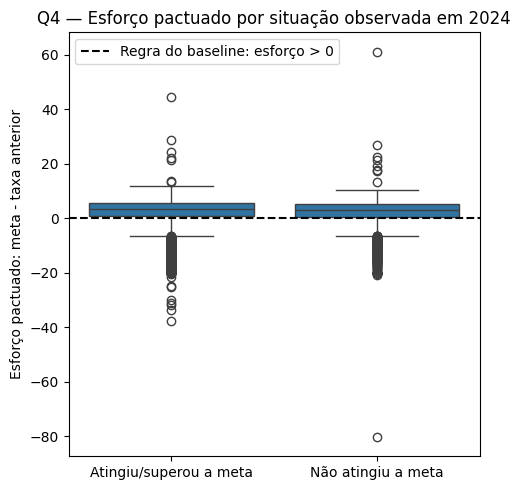

In [62]:
base_esforco_2024 = dados_q4.loc[
    dados_q4['ano'].eq(2024)
    & dados_q4['esforco_pactuado'].notna()
    & dados_q4[TARGET_Q4].notna(),
    ['esforco_pactuado', TARGET_Q4]
].copy()

base_esforco_2024['Situação observada'] = (
    pd.to_numeric(base_esforco_2024[TARGET_Q4], errors='raise')
    .astype(int)
    .map({
        0: 'Atingiu/superou a meta',
        1: 'Não atingiu a meta',
    })
)

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(
    data=base_esforco_2024,
    x='Situação observada',
    y='esforco_pactuado',
    ax=ax,
)
ax.axhline(
    0,
    color='black',
    linestyle='--',
    label='Regra do baseline: esforço > 0',
)
ax.set_title('Q4 — Esforço pactuado por situação observada em 2024')
ax.set_xlabel('')
ax.set_ylabel('Esforço pactuado: meta - taxa anterior')
ax.legend()
plt.tight_layout()
plt.show()


Esforço pactuado (a diferença entre a meta e a taxa anterior) não é um bom discriminador para prever se a meta será atingida ou não.

## 6. Distribuição do target de Q4

Agora observamos a prevalência de `risco_nao_atingir_meta` em cada ano **na população já elegível para Q4**.

Esta análise descreve:

1. o percentual de municípios que não atingiu a meta em 2024;
2. o percentual correspondente em 2025;
3. a composição das classes em cada período;
4. a mudança temporal de prevalência.

A distribuição de 2025 é apenas descritiva. A decisão de usar `class_weight='balanced'` é motivada pela prioridade operacional de reduzir falsos negativos e será julgada pelo desempenho de desenvolvimento em 2024, sem usar 2025 para selecionar ou ajustar o modelo.

**Mensagem de negócio:** o gráfico de prevalência evidencia a mudança temporal no contexto de cumprimento das metas municipais.


In [63]:
base_target_q4 = dados_q4.loc[
    dados_q4['ano'].isin(ANOS_ANALISE) & dados_q4[TARGET_Q4].notna(),
    ['ano', 'id_municipio', TARGET_Q4]
].copy()

base_target_q4[TARGET_Q4] = pd.to_numeric(
    base_target_q4[TARGET_Q4],
    errors='raise'
).astype(int)

distribuicao_q4 = (
    base_target_q4
    .groupby(['ano', TARGET_Q4])
    .size()
    .rename('municipios')
    .reset_index()
)

totais_ano_q4 = (
    base_target_q4.groupby('ano')
    .size()
    .rename('total_municipios')
)

distribuicao_q4['percentual'] = (
    distribuicao_q4['municipios']
    / distribuicao_q4['ano'].map(totais_ano_q4)
    * 100
)

distribuicao_q4['classe'] = distribuicao_q4[TARGET_Q4].map({
    0: 'Atingiu/superou a meta',
    1: 'Não atingiu a meta',
})

tabela_distribuicao_q4 = (
    distribuicao_q4[
        ['ano', 'classe', 'municipios', 'percentual']
    ]
    .sort_values(['ano', 'classe'])
    .reset_index(drop=True)
)

display(tabela_distribuicao_q4)

,ano,classe,municipios,percentual
0,2024,Atingiu/superou a meta,2948,54.331
1,2024,Não atingiu a meta,2478,45.669
2,2025,Atingiu/superou a meta,3953,72.492
3,2025,Não atingiu a meta,1500,27.508


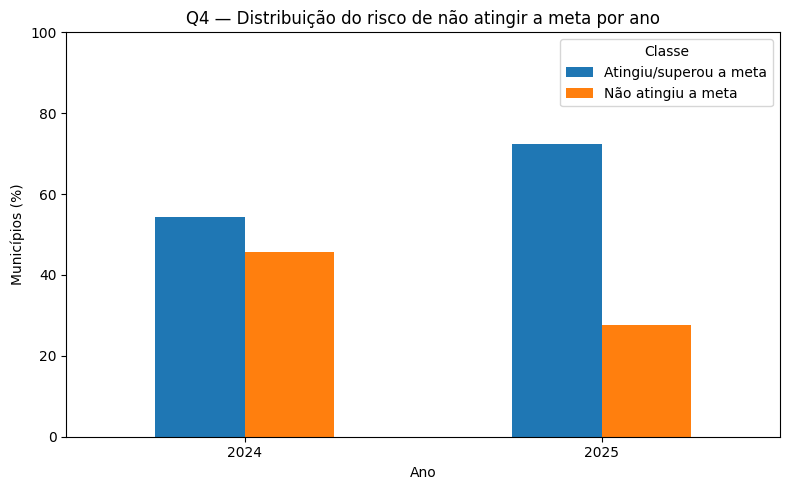

In [64]:
grafico_q4 = (
    distribuicao_q4
    .pivot(index='ano', columns='classe', values='percentual')
    .fillna(0)
)

ax = grafico_q4.plot(
    kind='bar',
    figsize=(8, 5)
)

ax.set_title('Q4 — Distribuição do risco de não atingir a meta por ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Municípios (%)')
ax.set_ylim(0, max(100, grafico_q4.to_numpy().max() * 1.15))
ax.legend(title='Classe')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Prevalência de não atingimento de meta: 2024 versus 2025

O foco agora é isolar a classe positiva (`risco_nao_atingir_meta = 1`) e comparar sua prevalência entre os dois anos.

**Mensagem de negócio:** evidencia a mudança temporal no contexto de cumprimento das metas municipais.


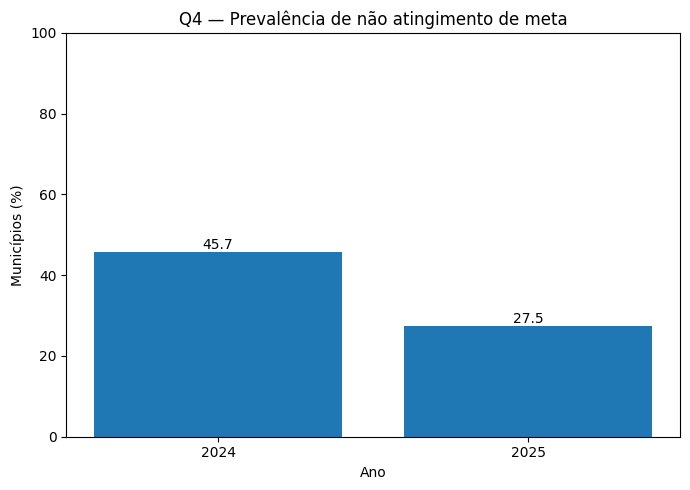

In [65]:
prevalencia_q4_plot = (
    distribuicao_q4.loc[distribuicao_q4['classe'].eq('Não atingiu a meta')]
    .sort_values('ano')
    .copy()
)

fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(
    prevalencia_q4_plot['ano'].astype(str),
    prevalencia_q4_plot['percentual'],
)
ax.set_title('Q4 — Prevalência de não atingimento de meta')
ax.set_xlabel('Ano')
ax.set_ylabel('Municípios (%)')
ax.set_ylim(0, max(100, prevalencia_q4_plot['percentual'].max() * 1.20))
ax.bar_label(barras, fmt='%.1f')
plt.tight_layout()
plt.show()


## 7. Estabilidade temporal do target

Além da distribuição em cada ano, precisamos entender quantos municípios mudaram de condição entre 2024 e 2025.

Consideramos somente os municípios:

- presentes nos dois anos;
- com `risco_nao_atingir_meta` válido em 2024 e 2025.

As quatro transições possíveis são:

- atingiu → atingiu;
- atingiu → não atingiu;
- não atingiu → atingiu;
- não atingiu → não atingiu.

Essa tabela é **descritiva**. Ela não mede desempenho de modelo e não deve ser usada para ajustar o teste temporal de 2025.

In [66]:
risco_meta_por_ano = (
    base_target_q4
    .pivot(index='id_municipio', columns='ano', values=TARGET_Q4)
    .dropna(subset=[2024, 2025])
    .rename(columns={
        2024: 'risco_2024',
        2025: 'risco_2025',
    })
    .astype(int)
)

rotulo_meta = {
    0: 'Atingiu',
    1: 'Não atingiu',
}

risco_meta_por_ano['transicao'] = (
    risco_meta_por_ano['risco_2024'].map(rotulo_meta)
    + ' → '
    + risco_meta_por_ano['risco_2025'].map(rotulo_meta)
)

transicoes_q4 = (
    risco_meta_por_ano['transicao']
    .value_counts()
    .rename('municipios')
    .to_frame()
)

transicoes_q4['percentual'] = (
    transicoes_q4['municipios']
    / len(risco_meta_por_ano)
    * 100
)

print(f'Municípios comparáveis em 2024 e 2025: {len(risco_meta_por_ano):,}')
display(transicoes_q4)

n_passou_nao_atingir = int(
    ((risco_meta_por_ano['risco_2024'] == 0)
     & (risco_meta_por_ano['risco_2025'] == 1)).sum()
)

n_passou_atingir = int(
    ((risco_meta_por_ano['risco_2024'] == 1)
     & (risco_meta_por_ano['risco_2025'] == 0)).sum()
)

n_permaneceu_nao_atingir = int(
    ((risco_meta_por_ano['risco_2024'] == 1)
     & (risco_meta_por_ano['risco_2025'] == 1)).sum()
)

n_permaneceu_atingiu = int(
    ((risco_meta_por_ano['risco_2024'] == 0)
     & (risco_meta_por_ano['risco_2025'] == 0)).sum()
)

print(f'Atingiu → não atingiu:      {n_passou_nao_atingir:,}')
print(f'Não atingiu → atingiu:      {n_passou_atingir:,}')
print(f'Não atingiu → não atingiu:  {n_permaneceu_nao_atingir:,}')
print(f'Atingiu → atingiu:          {n_permaneceu_atingiu:,}')

Municípios comparáveis em 2024 e 2025: 5,414


,municipios,percentual
transicao,,
Atingiu → Atingiu,2556,47.211
Não atingiu → Atingiu,1380,25.489
Não atingiu → Não atingiu,1090,20.133
Atingiu → Não atingiu,388,7.167


Atingiu → não atingiu:      388
Não atingiu → atingiu:      1,380
Não atingiu → não atingiu:  1,090
Atingiu → atingiu:          2,556


## 8. Conclusões parciais

As auditorias permitem avançar com algumas decisões explícitas:

- a unidade município-ano está íntegra, sem duplicidades;
- `risco_nao_atingir_meta` respeita a regra `taxa_realizada < meta` na população elegível;
- `meta`, `taxa_lag1` e `esforco_pactuado` foram auditados;
- `esforco_pactuado` foi validado como `meta - taxa_lag1`;
- a prevalência do target pode mudar entre os anos, mas 2025 não será usado para tomar decisões de desenvolvimento.

### Decisões adotadas a partir daqui

1. **Usar a população elegível já filtrada no início do notebook.**  
   Registros com `meta == 0` ou `taxa_realizada == 0` permanecem excluídos em todas as etapas seguintes.

2. **Usar `class_weight='balanced'` nos classificadores treináveis.**  
   A justificativa é operacional: em Q4, falsos negativos são especialmente custosos. A adequação dessa escolha será avaliada somente por cross-validation em 2024.

3. **Evitar redundância perfeita entre `meta`, `taxa_lag1` e `esforco_pactuado`.**  
   Como `esforco_pactuado = meta - taxa_lag1`, manteremos `meta` e `esforco_pactuado` em `X` e retiraremos `taxa_lag1` do conjunto preditivo.

4. **Usar somente as variáveis já disponíveis no projeto e bloquear variáveis pós-desfecho.**  
   A disponibilidade temporal das features deve ser compatível com o momento real da previsão; o checklist posterior mantém a auditoria contra leakage explícito.

5. **Manter 2025 fora do desenvolvimento.**  
   Modelo, features, preprocessing e threshold serão definidos exclusivamente com 2024. O ano de 2025 permanece reservado para a avaliação temporal independente.

A próxima etapa será:

> **features finais → desenvolvimento 2024 → preprocessing numérico → baselines → modelos candidatos → cross-validation**


## 9. Verificação defensiva da elegibilidade de Q4

Os filtros de `meta == 0` e `taxa_realizada == 0` já foram aplicados no início do notebook.

Aqui mantemos apenas `asserts` defensivos para garantir que registros inelegíveis não reapareceram e que o target continua consistente com `taxa_realizada < meta`.


In [67]:
assert not dados_q4[COLUNA_META].eq(0).any(), (
    'Foram encontrados registros com meta == 0 após o filtro inicial.'
)
assert not dados_q4[COLUNA_TAXA].eq(0).any(), (
    'Foram encontrados registros com taxa_realizada == 0 após o filtro inicial.'
)

mascara_revalidacao = (
    dados_q4[TARGET_Q4].notna()
    & dados_q4[COLUNA_TAXA].notna()
    & dados_q4[COLUNA_META].notna()
)

target_esperado_filtrado = (
    dados_q4.loc[mascara_revalidacao, COLUNA_TAXA]
    < dados_q4.loc[mascara_revalidacao, COLUNA_META]
).astype(int)

target_observado_filtrado = pd.to_numeric(
    dados_q4.loc[mascara_revalidacao, TARGET_Q4],
    errors='raise',
).astype(int)

assert target_observado_filtrado.equals(target_esperado_filtrado), (
    'O target deixou de estar consistente com taxa_realizada < meta.'
)

print('Elegibilidade e consistência do target confirmadas por asserts defensivos.')


Elegibilidade e consistência do target confirmadas por asserts defensivos.


## 10. Revisão final das features de Q4

Partimos das features candidatas já auditadas.

Para manter o modelo simples e interpretável, retiramos `taxa_lag1` de `X`, pois:

```text
esforco_pactuado = meta - taxa_lag1
```

Logo, utilizar simultaneamente `meta`, `taxa_lag1` e `esforco_pactuado` introduziria uma relação algébrica
perfeita entre três variáveis.

Nesta primeira rodada não criaremos novas transformações além do preprocessing necessário aos modelos.
O objetivo é medir quanto os modelos básicos conseguem aprender usando as features já disponíveis.


In [68]:
FEATURES_Q4 = [
    c for c in FEATURES_CANDIDATAS_Q4
    if c != 'taxa_lag1'
]

print(f'Número de features finais de Q4: {len(FEATURES_Q4)}')
display(pd.DataFrame({'feature': FEATURES_Q4}))

# Verificações de segurança contra leakage e redundância deliberadamente removida.
assert TARGET_Q4 not in FEATURES_Q4
assert 'taxa_realizada' not in FEATURES_Q4
assert 'risco_educacional' not in FEATURES_Q4
assert 'distancia_ate_a_meta' not in FEATURES_Q4
assert 'id_municipio' not in FEATURES_Q4
assert 'id_uf' not in FEATURES_Q4
assert 'ano' not in FEATURES_Q4
assert 'taxa_lag1' not in FEATURES_Q4

# Features centrais de Q4 devem permanecer.
assert 'meta' in FEATURES_Q4
assert 'esforco_pactuado' in FEATURES_Q4

print('Features finais validadas.')


Número de features finais de Q4: 37


,feature
0,ctx_atlas_expectativa_anos_estudo
1,ctx_atlas_idhm_longevidade
2,ctx_atlas_indice_gini
3,ctx_atlas_percentual_domicilios_agua
4,ctx_atlas_percentual_domicilios_energia
5,ctx_atlas_taxa_analfabetismo_11a14
6,ctx_atlas_taxa_analfabetismo_15a17
7,ctx_atlas_taxa_analfabetismo_15mais
8,ctx_atlas_taxa_densidade_domiciliar
9,ctx_atlas_taxa_fora_escola_4a5


Features finais validadas.


## 11. Dados de desenvolvimento — somente 2024

Toda comparação de modelos será feita somente com 2024.

Nesta etapa:

- excluímos apenas registros sem target válido;
- mantemos nulos das features para serem tratados dentro do `Pipeline`;
- separamos os identificadores apenas para uso posterior;
- não criamos ainda o conjunto de teste de 2025.

Isso preserva 2025 como teste temporal final.


In [69]:
dados_q4_2024 = dados_q4.loc[
    dados_q4['ano'].eq(2024)
    & dados_q4[TARGET_Q4].notna()
].copy()

X_q4_2024 = dados_q4_2024[FEATURES_Q4].copy()

y_q4_2024 = pd.to_numeric(
    dados_q4_2024[TARGET_Q4],
    errors='raise'
).astype(int)


assert X_q4_2024.index.equals(y_q4_2024.index)
assert not y_q4_2024.isna().any()
assert set(y_q4_2024.unique()).issubset({0, 1})
assert set(dados_q4_2024['ano'].unique()) == {2024}

# Auditoria contra leakage.
for coluna_proibida in [
    'taxa_realizada',
    'risco_nao_atingir_meta',
    'risco_educacional',
    'distancia_ate_a_meta',
    'id_municipio',
    'id_uf',
    'ano',
]:
    assert coluna_proibida not in X_q4_2024.columns

print('Shape de X_q4_2024:', X_q4_2024.shape)
print('Shape de y_q4_2024:', y_q4_2024.shape)

distribuicao_dev_q4 = (
    y_q4_2024
    .value_counts()
    .sort_index()
    .rename('municipios')
    .to_frame()
)

distribuicao_dev_q4['percentual'] = (
    distribuicao_dev_q4['municipios']
    / len(y_q4_2024)
    * 100
)

distribuicao_dev_q4.index = distribuicao_dev_q4.index.map({
    0: 'Atingiu/superou a meta',
    1: 'Não atingiu a meta',
})

display(distribuicao_dev_q4)


Shape de X_q4_2024: (5426, 37)
Shape de y_q4_2024: (5426,)


,municipios,percentual
risco_nao_atingir_meta,,
Atingiu/superou a meta,2948,54.331
Não atingiu a meta,2478,45.669


## 12. Features numéricas e preprocessing

As **features finais de Q4 são numéricas**. Portanto, não precisamos criar um ramo categórico nem utilizar `OneHotEncoder`.

Antes de montar os pipelines, confirmamos programaticamente que nenhuma feature não numérica entrou em `X`.

Usaremos dois preprocessadores simples:

### Regressão Logística

```text
features numéricas
→ SimpleImputer(strategy='median')
→ StandardScaler
```

A regressão logística recebe `StandardScaler` porque trabalha melhor quando as variáveis estão em escalas comparáveis.

### Decision Tree

```text
features numéricas
→ SimpleImputer(strategy='median')
```

A árvore não precisa de padronização.

O `ColumnTransformer` será mantido apenas para deixar explícito quais colunas entram no preprocessing e para garantir que a imputação e o scaling continuem dentro do `Pipeline` durante a cross-validation.


In [70]:
# Todas as features utilizadas nesta etapa devem ser numéricas.
features_nao_numericas_q4 = X_q4_2024.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print('Features não numéricas encontradas:', features_nao_numericas_q4)

assert not features_nao_numericas_q4, (
    'Foram encontradas features não numéricas em X_q4_2024. '
    'Revise FEATURES_Q4 antes de continuar.'
)

features_numericas_q4 = X_q4_2024.columns.tolist()

print(f'Features numéricas utilizadas: {len(features_numericas_q4)}')
print(features_numericas_q4)

pipeline_numerico_logistica = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

pipeline_numerico_arvore = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

preprocessador_logistica = ColumnTransformer([
    ('num', pipeline_numerico_logistica, features_numericas_q4),
])

preprocessador_arvore = ColumnTransformer([
    ('num', pipeline_numerico_arvore, features_numericas_q4),
])

print('\nPreprocessing definido:')
print('- Regressão Logística: SimpleImputer → StandardScaler')
print('- Decision Tree: SimpleImputer')


Features não numéricas encontradas: []
Features numéricas utilizadas: 37
['ctx_atlas_expectativa_anos_estudo', 'ctx_atlas_idhm_longevidade', 'ctx_atlas_indice_gini', 'ctx_atlas_percentual_domicilios_agua', 'ctx_atlas_percentual_domicilios_energia', 'ctx_atlas_taxa_analfabetismo_11a14', 'ctx_atlas_taxa_analfabetismo_15a17', 'ctx_atlas_taxa_analfabetismo_15mais', 'ctx_atlas_taxa_densidade_domiciliar', 'ctx_atlas_taxa_fora_escola_4a5', 'ctx_atlas_taxa_fora_escola_6a14', 'ctx_atlas_taxa_frequencia_0a3', 'ctx_atlas_taxa_frequencia_liquida_fundamental', 'ctx_atlas_taxa_maes_10a14', 'ctx_atlas_taxa_maes_chefes_familia', 'ctx_atlas_taxa_trabalho_infantil_10a14', 'ctx_atu_creche', 'ctx_atu_educacao_infantil', 'ctx_atu_fundamental_1_ano', 'ctx_atu_fundamental_2_ano', 'ctx_atu_fundamental_3_ano', 'ctx_atu_fundamental_4_ano', 'ctx_atu_fundamental_5_ano', 'ctx_atu_fundamental_anos_iniciais', 'ctx_atu_pre_escola', 'ctx_fundeb_nse_uf', 'ctx_ibge_area_km2', 'ctx_ibge_pct_esgoto_adequado', 'ctx_ibge_pc

## 13. Baselines

Antes de comparar modelos de Machine Learning, precisamos de referências simples.

### Baseline estatístico

Usaremos `DummyClassifier(strategy='most_frequent')`, que sempre prevê a classe mais frequente.

### Baseline de negócio

Também avaliaremos a regra:

> se `esforco_pactuado > 0`, prever risco de não atingir a meta.

Como `esforco_pactuado` possui alguns valores ausentes, a cobertura dessa regra é reportada explicitamente.

A comparação direta com a Regressão Logística será feita posteriormente **na mesma amostra em que o baseline de negócio é aplicável**, usando as predições OOF de 2024.


In [71]:
mascara_baseline_negocio = X_q4_2024['esforco_pactuado'].notna()

y_baseline_negocio = y_q4_2024.loc[mascara_baseline_negocio]
escore_baseline_negocio = X_q4_2024.loc[
    mascara_baseline_negocio,
    'esforco_pactuado'
]

pred_baseline_negocio = (
    escore_baseline_negocio > 0
).astype(int)

metricas_baseline_negocio = pd.Series({
    'cobertura_pct': mascara_baseline_negocio.mean() * 100,
    'PR_AUC': average_precision_score(
        y_baseline_negocio,
        escore_baseline_negocio
    ),
    'Recall': recall_score(
        y_baseline_negocio,
        pred_baseline_negocio,
        zero_division=0
    ),
    'Precision': precision_score(
        y_baseline_negocio,
        pred_baseline_negocio,
        zero_division=0
    ),
    'F1': f1_score(
        y_baseline_negocio,
        pred_baseline_negocio,
        zero_division=0
    ),
    'Balanced_Accuracy': balanced_accuracy_score(
        y_baseline_negocio,
        pred_baseline_negocio
    ),
    'ROC_AUC': roc_auc_score(
        y_baseline_negocio,
        escore_baseline_negocio
    ),
})

print('Baseline de negócio — esforço_pactuado > 0')
display(
    metricas_baseline_negocio
    .rename('valor')
    .to_frame()
)


Baseline de negócio — esforço_pactuado > 0


,valor
cobertura_pct,99.171
PR_AUC,0.445
Recall,0.814
Precision,0.462
F1,0.589
Balanced_Accuracy,0.506
ROC_AUC,0.488


## 14. Modelos candidatos

1. `DummyClassifier` — baseline estatístico;
2. `LogisticRegression` — modelo linear e interpretável;
3. `DecisionTreeClassifier` — modelo não linear simples.

Nos dois classificadores treináveis será utilizado:

```python
class_weight='balanced'
```

Essa configuração aumenta o peso relativo dos erros da classe menos frequente dentro de cada fold de treinamento.

Ela **não garante** melhor resultado. A adequação será julgada pelas métricas de validação.


In [72]:
modelo_dummy = DummyClassifier(
    strategy='most_frequent'
)

modelo_logistica = Pipeline([
    ('preprocessador', preprocessador_logistica),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    )),
])

modelo_arvore = Pipeline([
    ('preprocessador', preprocessador_arvore),
    ('modelo', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
    )),
])

modelos_q4 = {
    'Dummy': modelo_dummy,
    'Regressão Logística': modelo_logistica,
    'Árvore de Decisão': modelo_arvore,
}

print('Modelos preparados:')
for nome in modelos_q4:
    print('-', nome)


Modelos preparados:
- Dummy
- Regressão Logística
- Árvore de Decisão


## 15. Cross-validation em 2024

Usaremos `StratifiedKFold` com 5 folds.

O termo **stratified** significa que cada fold preserva aproximadamente a proporção entre municípios que
atingiram e não atingiram a meta.

Para cada modelo calcularemos:

- PR-AUC;
- Recall;
- Precision;
- F1;
- Balanced Accuracy;
- ROC-AUC.

Também guardaremos a PR-AUC de treino para comparar treino e validação.

O objetivo do `gap` é simples:

> se o modelo for muito melhor no treino do que na validação, pode estar sobreajustando os dados.

2025 não participa desta etapa.


In [73]:
cv_q4 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring_q4 = {
    'pr_auc': 'average_precision',
    'recall': make_scorer(
        recall_score,
        zero_division=0
    ),
    'precision': make_scorer(
        precision_score,
        zero_division=0
    ),
    'f1': make_scorer(
        f1_score,
        zero_division=0
    ),
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
}

linhas_resultados_cv = []

for nome_modelo, estimador in modelos_q4.items():
    print(f'Avaliando: {nome_modelo}')

    resultado_cv = cross_validate(
        estimador,
        X_q4_2024,
        y_q4_2024,
        cv=cv_q4,
        scoring=scoring_q4,
        return_train_score=True,
        n_jobs=-1,
        error_score='raise',
    )

    pr_auc_cv = resultado_cv['test_pr_auc'].mean()
    pr_auc_treino = resultado_cv['train_pr_auc'].mean()

    linhas_resultados_cv.append({
        'Modelo': nome_modelo,
        'PR_AUC_CV': pr_auc_cv,
        'PR_AUC_CV_std': resultado_cv['test_pr_auc'].std(),
        'Recall_CV': resultado_cv['test_recall'].mean(),
        'Precision_CV': resultado_cv['test_precision'].mean(),
        'F1_CV': resultado_cv['test_f1'].mean(),
        'Balanced_Accuracy_CV': resultado_cv[
            'test_balanced_accuracy'
        ].mean(),
        'ROC_AUC_CV': resultado_cv['test_roc_auc'].mean(),
        'PR_AUC_treino': pr_auc_treino,
        'Gap_PR_AUC': pr_auc_treino - pr_auc_cv,
    })

tabela_cv_q4 = pd.DataFrame(linhas_resultados_cv)

colunas_numericas_resultados = tabela_cv_q4.columns.drop('Modelo')

tabela_cv_q4[colunas_numericas_resultados] = (
    tabela_cv_q4[colunas_numericas_resultados]
    .round(3)
)

print('\nComparação inicial — cross-validation em 2024')
display(tabela_cv_q4)


Avaliando: Dummy
Avaliando: Regressão Logística
Avaliando: Árvore de Decisão

Comparação inicial — cross-validation em 2024


,Modelo,PR_AUC_CV,PR_AUC_CV_std,Recall_CV,Precision_CV,F1_CV,Balanced_Accuracy_CV,ROC_AUC_CV,PR_AUC_treino,Gap_PR_AUC
0,Dummy,0.457,0.000,0.000,0.000,0.000,0.500,0.500,0.457,0.000
1,Regressão Logística,0.677,0.021,0.685,0.632,0.657,0.675,0.739,0.689,0.012
2,Árvore de Decisão,0.547,0.014,0.599,0.607,0.603,0.636,0.636,1.000,0.453


## 16. Escolha do modelo

A comparação por cross-validation em 2024 sustenta a escolha da **Regressão Logística** como modelo de Q4.

### Baselines

O baseline de negócio `esforco_pactuado > 0` tem valor por ser simples e facilmente explicável, mas os outputs mostram que ele tem **baixa capacidade de discriminação**. A distribuição de `esforco_pactuado` apresenta forte sobreposição entre municípios que atingiram e não atingiram a meta, e as métricas do baseline ficam próximas de uma separação aleatória em ROC-AUC e Balanced Accuracy.

Assim, `esforco_pactuado` isoladamente não é suficiente para separar bem os municípios de maior risco, embora continue útil como referência operacional.

### Árvore de Decisão

A Árvore de Decisão apresenta desempenho de validação inferior ao da Regressão Logística e um **gap muito elevado entre treino e validação**, caracterizando forte sobreajuste. Por isso, não há evidência para avançar com tuning desse modelo nesta etapa.

### Regressão Logística

A Regressão Logística apresenta o melhor equilíbrio entre:

- capacidade de discriminação;
- PR-AUC;
- F1 e Balanced Accuracy;
- estabilidade entre treino e validação;
- simplicidade e auditabilidade.

Além disso, quando comparada ao baseline de negócio **na mesma amostra**, a Regressão Logística melhora claramente a capacidade de ordenação e o equilíbrio entre Precision e Recall.

### Decisão

O modelo selecionado para Q4 permanece:

```python
LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)
```

Não será realizado tuning de hiperparâmetros. A próxima decisão é exclusivamente operacional: definir o **threshold**, usando apenas os scores OOF de 2024.

O threshold padrão de `0,50` permanece apenas como referência e não como decisão final.


## 17. Scores out-of-fold da Regressão Logística

Para estudar o threshold sem usar 2025, precisamos de saídas para 2024 em que cada município seja avaliado por um modelo que **não foi treinado com aquele próprio registro**.

Usaremos `cross_val_predict(..., method='predict_proba')` com o mesmo `StratifiedKFold` de 5 folds.

O fluxo é:

```text
folds de 2024
→ treino em 4 folds
→ score no fold restante
→ repetir para todos os folds
→ um score OOF para cada município
```

A saída de `predict_proba` será usada operacionalmente como **score de risco**. Como não foi feita uma análise de calibração, ela não deve ser interpretada automaticamente como probabilidade calibrada.

Esses scores OOF pertencem ao **desenvolvimento de 2024**. Eles orientam a comparação de modelos e a escolha do threshold, mas não constituem uma segunda validação independente do threshold. A avaliação independente e principal permanece sendo o teste temporal de 2025.


In [74]:
modelo_q4_selecionado = modelo_logistica

prob_oof_q4_2024 = cross_val_predict(
    modelo_q4_selecionado,
    X_q4_2024,
    y_q4_2024,
    cv=cv_q4,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

assert len(prob_oof_q4_2024) == len(y_q4_2024)
assert np.all((prob_oof_q4_2024 >= 0) & (prob_oof_q4_2024 <= 1))

pr_auc_oof = average_precision_score(
    y_q4_2024,
    prob_oof_q4_2024,
)

roc_auc_oof = roc_auc_score(
    y_q4_2024,
    prob_oof_q4_2024,
)

print(f'Scores OOF gerados: {len(prob_oof_q4_2024):,}')
print(f'PR-AUC OOF:  {pr_auc_oof:.3f}')
print(f'ROC-AUC OOF: {roc_auc_oof:.3f}')

# Comparação metodologicamente homogênea:
# Regressão Logística OOF e baseline de negócio avaliados na mesma amostra.
mascara_baseline_array = mascara_baseline_negocio.to_numpy()

y_q4_2024_amostra_baseline = y_q4_2024.loc[mascara_baseline_negocio]
score_logistica_oof_amostra_baseline = prob_oof_q4_2024[mascara_baseline_array]
pred_logistica_oof_amostra_baseline = (
    score_logistica_oof_amostra_baseline >= 0.50
).astype(int)

comparacao_baseline_mesma_amostra_q4 = pd.DataFrame([
    {
        'Modelo': 'Baseline esforço_pactuado > 0',
        'Cobertura_pct': mascara_baseline_negocio.mean() * 100,
        'PR_AUC': average_precision_score(
            y_q4_2024_amostra_baseline,
            escore_baseline_negocio,
        ),
        'ROC_AUC': roc_auc_score(
            y_q4_2024_amostra_baseline,
            escore_baseline_negocio,
        ),
        'Recall': recall_score(
            y_q4_2024_amostra_baseline,
            pred_baseline_negocio,
            zero_division=0,
        ),
        'Precision': precision_score(
            y_q4_2024_amostra_baseline,
            pred_baseline_negocio,
            zero_division=0,
        ),
        'F1': f1_score(
            y_q4_2024_amostra_baseline,
            pred_baseline_negocio,
            zero_division=0,
        ),
        'Balanced_Accuracy': balanced_accuracy_score(
            y_q4_2024_amostra_baseline,
            pred_baseline_negocio,
        ),
    },
    {
        'Modelo': 'Regressão Logística OOF (threshold 0,50)',
        'Cobertura_pct': mascara_baseline_negocio.mean() * 100,
        'PR_AUC': average_precision_score(
            y_q4_2024_amostra_baseline,
            score_logistica_oof_amostra_baseline,
        ),
        'ROC_AUC': roc_auc_score(
            y_q4_2024_amostra_baseline,
            score_logistica_oof_amostra_baseline,
        ),
        'Recall': recall_score(
            y_q4_2024_amostra_baseline,
            pred_logistica_oof_amostra_baseline,
            zero_division=0,
        ),
        'Precision': precision_score(
            y_q4_2024_amostra_baseline,
            pred_logistica_oof_amostra_baseline,
            zero_division=0,
        ),
        'F1': f1_score(
            y_q4_2024_amostra_baseline,
            pred_logistica_oof_amostra_baseline,
            zero_division=0,
        ),
        'Balanced_Accuracy': balanced_accuracy_score(
            y_q4_2024_amostra_baseline,
            pred_logistica_oof_amostra_baseline,
        ),
    },
])

print('\nComparação na mesma amostra do baseline de negócio')
display(comparacao_baseline_mesma_amostra_q4.round(3))


Scores OOF gerados: 5,426
PR-AUC OOF:  0.673
ROC-AUC OOF: 0.738

Comparação na mesma amostra do baseline de negócio


,Modelo,Cobertura_pct,PR_AUC,ROC_AUC,Recall,Precision,F1,Balanced_Accuracy
0,Baseline esforço_pactuado > 0,99.171,0.445,0.488,0.814,0.462,0.589,0.506
1,"Regressão Logística OOF (threshold 0,50)",99.171,0.676,0.739,0.688,0.634,0.660,0.676


## 18. Avaliação de thresholds

O threshold define quando o **score de risco** será convertido em classe prevista:

```text
score >= threshold
→ município sinalizado como risco
```

O objetivo não é apenas observar uma tabela, mas tornar explícito o **trade-off operacional** entre:

- maior cobertura dos municípios vulneráveis (**Recall**);
- maior proporção de alertas corretos (**Precision**);
- equilíbrio entre as duas dimensões (**F1**);
- quantidade de alertas adicionais (**falsos positivos**) e de riscos perdidos (**falsos negativos**).

Os gráficos a seguir transformam a escolha do threshold em uma decisão operacional explícita.


In [75]:
thresholds_q4 = [0.30, 0.40, 0.50, 0.60, 0.70]
linhas_threshold = []

for threshold in thresholds_q4:
    pred_threshold = (
        prob_oof_q4_2024 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_q4_2024,
        pred_threshold,
        labels=[0, 1],
    ).ravel()

    n_sinalizados = int(pred_threshold.sum())

    linhas_threshold.append({
        'Threshold': threshold,
        'Recall': recall_score(
            y_q4_2024,
            pred_threshold,
            zero_division=0,
        ),
        'Precision': precision_score(
            y_q4_2024,
            pred_threshold,
            zero_division=0,
        ),
        'F1': f1_score(
            y_q4_2024,
            pred_threshold,
            zero_division=0,
        ),
        'Balanced_Accuracy': balanced_accuracy_score(
            y_q4_2024,
            pred_threshold,
        ),
        'Municipios_sinalizados': n_sinalizados,
        'Percentual_sinalizado': (
            n_sinalizados / len(y_q4_2024) * 100
        ),
        'Falsos_negativos': int(fn),
        'Falsos_positivos': int(fp),
        'Verdadeiros_positivos': int(tp),
        'Verdadeiros_negativos': int(tn),
    })

tabela_threshold_q4 = pd.DataFrame(linhas_threshold)

colunas_metricas_threshold = [
    'Recall',
    'Precision',
    'F1',
    'Balanced_Accuracy',
    'Percentual_sinalizado',
]

tabela_threshold_q4_exibicao = tabela_threshold_q4.copy()
tabela_threshold_q4_exibicao[colunas_metricas_threshold] = (
    tabela_threshold_q4_exibicao[colunas_metricas_threshold]
    .round(3)
)

print('Comparação de thresholds — scores OOF de desenvolvimento de 2024')
display(tabela_threshold_q4_exibicao)


Comparação de thresholds — scores OOF de desenvolvimento de 2024


,Threshold,Recall,Precision,F1,Balanced_Accuracy,Municipios_sinalizados,Percentual_sinalizado,Falsos_negativos,Falsos_positivos,Verdadeiros_positivos,Verdadeiros_negativos
0,0.300,0.940,0.528,0.676,0.617,4412,81.312,149,2083,2329,865
1,0.400,0.844,0.576,0.685,0.661,3633,66.955,386,1541,2092,1407
2,0.500,0.685,0.632,0.657,0.675,2688,49.539,780,990,1698,1958
3,0.600,0.492,0.692,0.575,0.654,1764,32.510,1258,544,1220,2404
4,0.700,0.293,0.738,0.419,0.603,983,18.116,1753,258,725,2690


In [76]:
THRESHOLD_Q4 = 0.40

linha_threshold_escolhido = tabela_threshold_q4.loc[
    np.isclose(tabela_threshold_q4['Threshold'], THRESHOLD_Q4)
].iloc[0]

linha_threshold_padrao = tabela_threshold_q4.loc[
    np.isclose(tabela_threshold_q4['Threshold'], 0.50)
].iloc[0]

maior_f1_avaliado = tabela_threshold_q4['F1'].max()

assert np.isclose(linha_threshold_escolhido['F1'], maior_f1_avaliado), (
    'O threshold 0,40 deixou de apresentar o maior F1 entre os valores avaliados. '
    'Revise a justificativa operacional antes de continuar.'
)

ganho_recall_vs_padrao = (
    linha_threshold_escolhido['Recall']
    - linha_threshold_padrao['Recall']
)
delta_bal_acc_vs_padrao = (
    linha_threshold_escolhido['Balanced_Accuracy']
    - linha_threshold_padrao['Balanced_Accuracy']
)

print(f'Threshold congelado: {THRESHOLD_Q4:.2f}')
print(f'Ganho de Recall vs. 0,50: {ganho_recall_vs_padrao:+.3f}')
print(f'Variação de Balanced Accuracy vs. 0,50: {delta_bal_acc_vs_padrao:+.3f}')
print('O threshold 0,40 apresenta o maior F1 entre os valores avaliados.')


Threshold congelado: 0.40
Ganho de Recall vs. 0,50: +0.159
Variação de Balanced Accuracy vs. 0,50: -0.014
O threshold 0,40 apresenta o maior F1 entre os valores avaliados.


### Trade-off operacional por threshold

Os dois painéis abaixo mostram a mesma decisão sob duas perspectivas:

- à esquerda, o equilíbrio entre **Recall, Precision, F1 e Balanced Accuracy**;
- à direita, o perfil de **falsos negativos e falsos positivos**.

A linha vertical marca o threshold operacional selecionado.

**Mensagem de negócio:** transforma a escolha do threshold em decisão explícita entre maior cobertura dos municípios vulneráveis e maior volume de alertas.


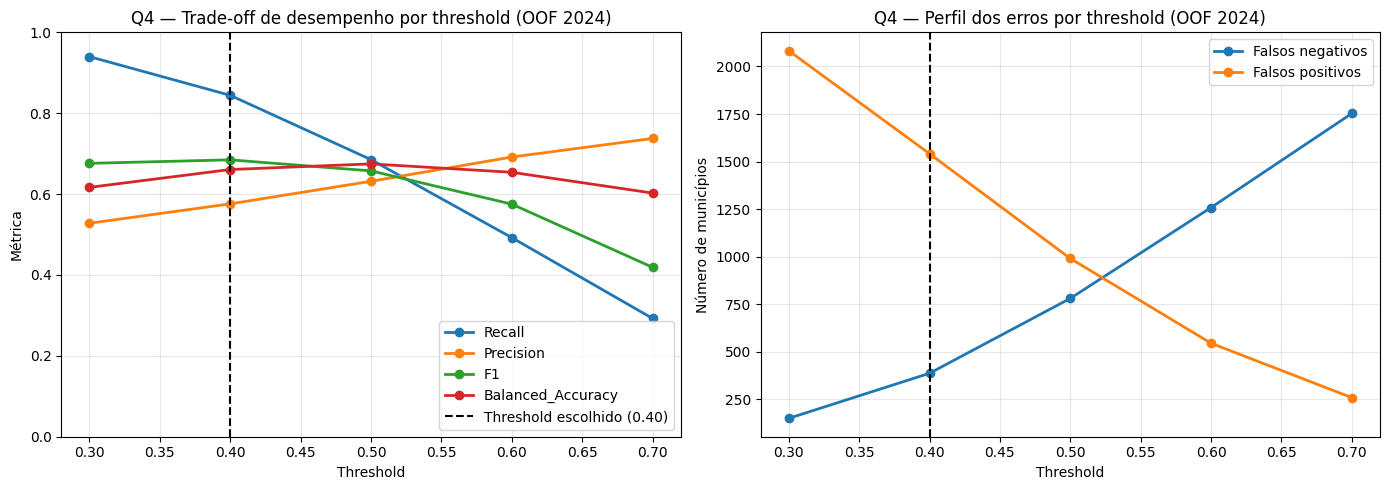

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metrica in ['Recall', 'Precision', 'F1', 'Balanced_Accuracy']:
    axes[0].plot(
        tabela_threshold_q4['Threshold'],
        tabela_threshold_q4[metrica],
        marker='o',
        linewidth=2,
        label=metrica,
    )

axes[0].axvline(
    THRESHOLD_Q4,
    color='black',
    linestyle='--',
    label=f'Threshold escolhido ({THRESHOLD_Q4:.2f})',
)
axes[0].set_ylim(0, 1)
axes[0].set_title('Q4 — Trade-off de desempenho por threshold (OOF 2024)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Métrica')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    tabela_threshold_q4['Threshold'],
    tabela_threshold_q4['Falsos_negativos'],
    marker='o',
    linewidth=2,
    label='Falsos negativos',
)
axes[1].plot(
    tabela_threshold_q4['Threshold'],
    tabela_threshold_q4['Falsos_positivos'],
    marker='o',
    linewidth=2,
    label='Falsos positivos',
)
axes[1].axvline(
    THRESHOLD_Q4,
    color='black',
    linestyle='--',
)
axes[1].set_title('Q4 — Perfil dos erros por threshold (OOF 2024)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Número de municípios')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 19. Conclusão da etapa de threshold

O threshold de `0,40` permanece a escolha mais adequada entre os valores avaliados em 2024.

Ele apresenta o **maior F1** e, em relação ao threshold padrão de `0,50`, aumenta de forma relevante o Recall com perda pequena de Balanced Accuracy. O gráfico de trade-off mostra claramente o efeito esperado:

- thresholds menores aumentam a cobertura dos municípios de risco, mas geram mais falsos positivos;
- thresholds maiores reduzem os alertas, porém deixam mais municípios de risco sem sinalização.

O valor `0,40` representa, portanto, uma decisão de **alta cobertura**, coerente com a prioridade de Q4 de reduzir falsos negativos. Isso tem um custo operacional importante: uma parcela elevada dos municípios é sinalizada e o número de falsos positivos permanece relevante.

As métricas OOF de 2024 são **métricas de desenvolvimento**. Elas orientam a escolha do threshold, mas não constituem validação independente, pois os mesmos scores OOF foram utilizados para comparar os thresholds.

A avaliação temporal independente e principal continua sendo 2025.

A partir deste ponto, o threshold fica congelado e não será alterado em função dos resultados de 2025.


Antes de comparar as matrizes de confusão, relembramos os quatro resultados possíveis no contexto da Q4:

- **Verdadeiro positivo (TP):** o município não atingiu a meta e o modelo o sinalizou como risco.
- **Falso positivo (FP):** o município atingiu/superou a meta, mas o modelo o sinalizou como risco.
- **Verdadeiro negativo (TN):** o município atingiu/superou a meta e o modelo não o sinalizou como risco.
- **Falso negativo (FN):** o município não atingiu a meta, mas o modelo não o sinalizou como risco.

Como a prioridade operacional da Q4 é reduzir municípios de risco não detectados, os **falsos negativos** recebem
atenção especial.

### 19.1 Contagens da matriz de confusão — desenvolvimento OOF de 2024

As contagens abaixo usam o threshold congelado e predições OOF.

Elas descrevem o **comportamento de desenvolvimento** do threshold em 2024. Como o threshold foi escolhido a partir desses próprios scores OOF, esta etapa não deve ser tratada como uma validação independente adicional.

A visualização gráfica das matrizes será mostrada apenas uma vez, mais adiante, na comparação lado a lado entre desenvolvimento OOF de 2024 e teste temporal de 2025.


In [78]:
pred_oof_q4_2024_threshold = (
    prob_oof_q4_2024 >= THRESHOLD_Q4
).astype(int)

tn_2024, fp_2024, fn_2024, tp_2024 = confusion_matrix(
    y_q4_2024,
    pred_oof_q4_2024_threshold,
    labels=[0, 1],
).ravel()

matriz_confusao_oof_2024 = np.array([
    [tn_2024, fp_2024],
    [fn_2024, tp_2024],
])

contagens_oof_2024 = pd.Series({
    'TN': int(tn_2024),
    'FP': int(fp_2024),
    'FN': int(fn_2024),
    'TP': int(tp_2024),
}, name='contagem')

display(contagens_oof_2024.to_frame())


,contagem
TN,1407
FP,1541
FN,386
TP,2092


## 20. Congelamento da configuração de Q4

Antes de abrir o teste temporal, registramos explicitamente a configuração final de desenvolvimento:

| Elemento | Configuração |
|---|---|
| Modelo | Regressão Logística |
| `class_weight` | `'balanced'` |
| Tuning | não realizado |
| Threshold | `0,40` |
| Features | conjunto final definido em `FEATURES_Q4` |
| Imputação | mediana, dentro do Pipeline |
| Scaling | `StandardScaler`, dentro do Pipeline |
| Métrica preditiva principal | PR-AUC |
| Métrica operacional prioritária | Recall |
| Desenvolvimento | 2024 |
| Teste temporal final | 2025 |

Nenhuma dessas decisões poderá ser modificada a partir do desempenho observado em 2025.

A saída de `predict_proba` será utilizada como **score de risco para ordenação e priorização**, salvo evidência posterior de calibração adequada.


In [79]:
CONFIGURACAO_Q4 = {
    'modelo': 'Regressão Logística',
    'class_weight': 'balanced',
    'threshold': THRESHOLD_Q4,
    'n_features': len(FEATURES_Q4),
    'preprocessamento': 'SimpleImputer(median) + StandardScaler',
    'metrica_principal': 'PR-AUC',
    'metrica_operacional': 'Recall',
    'ano_desenvolvimento': 2024,
    'ano_teste_temporal': 2025,
}

display(
    pd.Series(CONFIGURACAO_Q4, name='configuracao')
    .to_frame()
)

,configuracao
modelo,Regressão Logística
class_weight,balanced
threshold,0.400
n_features,37
preprocessamento,SimpleImputer(median) + StandardScaler
metrica_principal,PR-AUC
metrica_operacional,Recall
ano_desenvolvimento,2024
ano_teste_temporal,2025


## 21. Checklist automático contra leakage

Antes de utilizar 2025, executamos uma auditoria programática.

O objetivo é confirmar que:

- o desenvolvimento usa somente 2024;
- identificadores e variáveis pós-desfecho não aparecem em `X`;
- `taxa_lag1` continua fora de `X`, evitando redundância com `meta` e `esforco_pactuado`;
- imputação e scaling permanecem dentro do `Pipeline`;
- o threshold foi definido exclusivamente com probabilidades OOF de 2024.

In [80]:
# Elegibilidade já aplicada no início do fluxo.
assert not dados_q4[COLUNA_META].eq(0).any()
assert not dados_q4[COLUNA_TAXA].eq(0).any()

# Separação temporal do desenvolvimento.
assert set(dados_q4_2024['ano'].unique()) == {2024}

# Leakage e identificadores.
colunas_proibidas_q4 = [
    'taxa_realizada',
    'risco_nao_atingir_meta',
    'risco_educacional',
    'distancia_ate_a_meta',
    'proficiencia_media',
    'id_municipio',
    'id_uf',
    'nome_municipio',
    'ano',
]

for coluna in colunas_proibidas_q4:
    assert coluna not in X_q4_2024.columns, f'Leakage/identificador encontrado: {coluna}'

# Política do projeto e redundância.
assert 'pct_rede_municipal' not in X_q4_2024.columns
assert 'taxa_lag1' not in X_q4_2024.columns

# Configuração congelada.
assert THRESHOLD_Q4 == 0.40
assert modelo_q4_selecionado is modelo_logistica

# Preprocessing da Regressão Logística dentro do Pipeline.
# Como o objeto original ainda não foi ajustado em 100% de 2024,
# auditamos a definição do ColumnTransformer, e não atributos pós-fit.
preprocessador_auditado = modelo_q4_selecionado.named_steps['preprocessador']

transformadores_num = [
    transformador
    for nome, transformador, colunas in preprocessador_auditado.transformers
    if nome == 'num'
]

assert len(transformadores_num) == 1

pipeline_numerico_auditado = transformadores_num[0]

assert isinstance(
    pipeline_numerico_auditado.named_steps['imputer'],
    SimpleImputer
)
assert isinstance(
    pipeline_numerico_auditado.named_steps['scaler'],
    StandardScaler
)

print('Checklist contra leakage concluído.')
print('- desenvolvimento restrito a 2024')
print('- identificadores fora de X')
print('- variáveis pós-desfecho fora de X')
print('- pct_rede_municipal fora de X')
print('- taxa_lag1 fora de X')
print('- imputação dentro do Pipeline')
print('- scaling dentro do Pipeline')
print('- threshold congelado em 0,40')
print('- 2025 ainda não foi usado para desenvolvimento')


Checklist contra leakage concluído.
- desenvolvimento restrito a 2024
- identificadores fora de X
- variáveis pós-desfecho fora de X
- pct_rede_municipal fora de X
- taxa_lag1 fora de X
- imputação dentro do Pipeline
- scaling dentro do Pipeline
- threshold congelado em 0,40
- 2025 ainda não foi usado para desenvolvimento


## 22. Fit final em 100% de 2024

Com a configuração congelada, ajustamos uma nova cópia do pipeline usando todos os registros válidos de 2024.

Esse ajuste não é uma nova etapa de seleção. É apenas o treinamento final do modelo que será aplicado ao ano
seguinte.

In [81]:
modelo_q4_final = clone(modelo_q4_selecionado)

modelo_q4_final.fit(
    X_q4_2024,
    y_q4_2024,
)

print('Modelo final ajustado em 100% dos dados válidos de 2024.')
print(f'Registros usados no fit: {len(X_q4_2024):,}')
print(f'Features utilizadas: {X_q4_2024.shape[1]}')


Modelo final ajustado em 100% dos dados válidos de 2024.
Registros usados no fit: 5,426
Features utilizadas: 37


## 23. Preparação do teste temporal — 2025

Somente agora abrimos o conjunto supervisionado de 2025 para avaliação final.

Aplicamos exatamente as regras definidas anteriormente:

- registros com `meta == 0` já foram excluídos no início;
- registros com `taxa_realizada == 0` já foram excluídos como inválidos;
- o target precisa estar disponível para avaliação;
- usamos exatamente as mesmas `FEATURES_Q4`;
- não recalculamos medianas ou scaling manualmente;
- o Pipeline treinado em 2024 aplica suas transformações a 2025.

Os identificadores ficam separados e serão usados apenas nas análises posteriores de erros e ranking.


In [82]:
dados_q4_2025 = dados_q4.loc[
    dados_q4['ano'].eq(2025)
    & dados_q4[TARGET_Q4].notna()
].copy()

X_q4_2025 = dados_q4_2025[FEATURES_Q4].copy()

y_q4_2025 = pd.to_numeric(
    dados_q4_2025[TARGET_Q4],
    errors='raise',
).astype(int)

colunas_chave_2025 = [
    c for c in ['ano', 'id_uf', 'id_municipio', 'nome_municipio']
    if c in dados_q4_2025.columns
]

chaves_q4_2025 = adicionar_uf_regiao(
    dados_q4_2025[colunas_chave_2025].copy()
)

assert set(dados_q4_2025['ano'].unique()) == {2025}
assert X_q4_2025.columns.tolist() == X_q4_2024.columns.tolist()
assert X_q4_2025.index.equals(y_q4_2025.index)
assert not y_q4_2025.isna().any()
assert set(y_q4_2025.unique()).issubset({0, 1})

print('Shape de X_q4_2025:', X_q4_2025.shape)
print('Shape de y_q4_2025:', y_q4_2025.shape)

distribuicao_teste_q4 = (
    y_q4_2025
    .value_counts()
    .sort_index()
    .rename('municipios')
    .to_frame()
)

distribuicao_teste_q4['percentual'] = (
    distribuicao_teste_q4['municipios']
    / len(y_q4_2025)
    * 100
)

distribuicao_teste_q4.index = distribuicao_teste_q4.index.map({
    0: 'Atingiu/superou a meta',
    1: 'Não atingiu a meta',
})

display(distribuicao_teste_q4)

Shape de X_q4_2025: (5453, 37)
Shape de y_q4_2025: (5453,)


,municipios,percentual
risco_nao_atingir_meta,,
Atingiu/superou a meta,3953,72.492
Não atingiu a meta,1500,27.508


## 24. Teste temporal final — 2025

O modelo treinado em 2024 produz um **score de risco** para 2025 a partir de `predict_proba`.

A classe prevista será definida exclusivamente pelo threshold congelado:

```python
score >= 0.40
```

Calcularemos:

- PR-AUC;
- ROC-AUC;
- Recall;
- Precision;
- F1;
- Balanced Accuracy;
- Accuracy apenas como informação complementar;
- TN, FP, FN e TP.

Esses resultados medem **generalização temporal**. Depois de observá-los, não será permitido alterar modelo, features, preprocessing, `class_weight` ou threshold.

Sem uma análise específica de calibração, o valor retornado por `predict_proba` será interpretado como **score de risco**, e não como probabilidade calibrada do evento.

**Mensagem de negócio:** a curva Precision–Recall e a matriz de confusão normalizada mostram, em 2025, o ganho de priorização e a capacidade do modelo de captar municípios que não atingirão a meta.


In [83]:
prob_q4_2025 = modelo_q4_final.predict_proba(
    X_q4_2025
)[:, 1]

pred_q4_2025 = (
    prob_q4_2025 >= THRESHOLD_Q4
).astype(int)

tn_2025, fp_2025, fn_2025, tp_2025 = confusion_matrix(
    y_q4_2025,
    pred_q4_2025,
    labels=[0, 1],
).ravel()

metricas_q4_2025 = pd.Series({
    'PR_AUC': average_precision_score(
        y_q4_2025,
        prob_q4_2025,
    ),
    'ROC_AUC': roc_auc_score(
        y_q4_2025,
        prob_q4_2025,
    ),
    'Recall': recall_score(
        y_q4_2025,
        pred_q4_2025,
        zero_division=0,
    ),
    'Precision': precision_score(
        y_q4_2025,
        pred_q4_2025,
        zero_division=0,
    ),
    'F1': f1_score(
        y_q4_2025,
        pred_q4_2025,
        zero_division=0,
    ),
    'Balanced_Accuracy': balanced_accuracy_score(
        y_q4_2025,
        pred_q4_2025,
    ),
    'Accuracy': accuracy_score(
        y_q4_2025,
        pred_q4_2025,
    ),
    'Threshold': THRESHOLD_Q4,
    'Municipios_sinalizados': int(pred_q4_2025.sum()),
    'Percentual_sinalizado': (
        pred_q4_2025.mean() * 100
    ),
    'TN': int(tn_2025),
    'FP': int(fp_2025),
    'FN': int(fn_2025),
    'TP': int(tp_2025),
})

print('Métricas — teste temporal final de 2025')
display(
    metricas_q4_2025
    .round(3)
    .rename('valor')
    .to_frame()
)


Métricas — teste temporal final de 2025


,valor
PR_AUC,0.555
ROC_AUC,0.737
Recall,0.805
Precision,0.375
F1,0.512
Balanced_Accuracy,0.648
Accuracy,0.578
Threshold,0.400
Municipios_sinalizados,"3,216.000"
Percentual_sinalizado,58.977


### Curva Precision–Recall no teste temporal de 2025

A curva abaixo usa o **score de risco** do modelo em 2025 e inclui a prevalência observada como linha de referência.

**Mensagem de negócio:** demonstra o ganho de priorização em relação a selecionar municípios aleatoriamente.


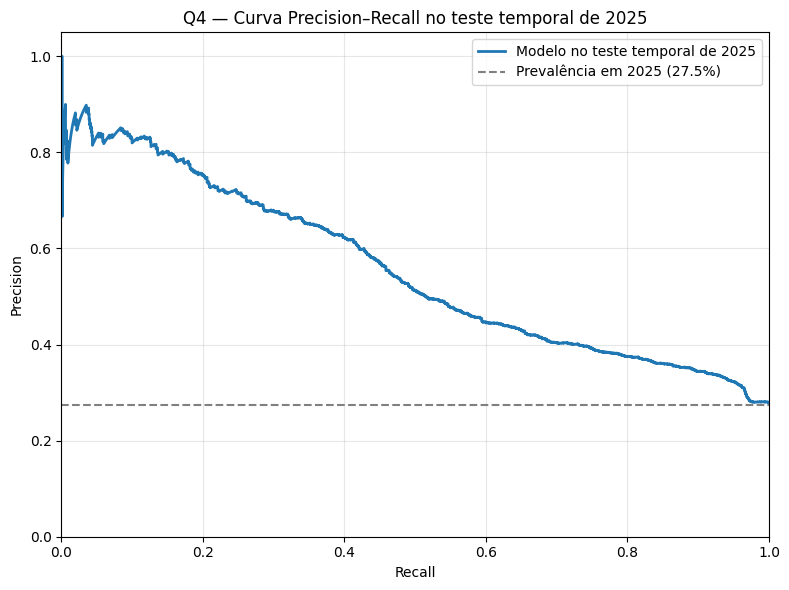

In [84]:
precision_q4_2025, recall_q4_2025, thresholds_pr_q4_2025 = (
    precision_recall_curve(
        y_q4_2025,
        prob_q4_2025,
    )
)

prevalencia_q4_2025 = y_q4_2025.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    recall_q4_2025,
    precision_q4_2025,
    linewidth=2,
    label='Modelo no teste temporal de 2025',
)

ax.axhline(
    prevalencia_q4_2025,
    color='gray',
    linestyle='--',
    label=f'Prevalência em 2025 ({prevalencia_q4_2025:.1%})',
)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Q4 — Curva Precision–Recall no teste temporal de 2025')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Diagnóstico de calibração do score em 2025

A curva abaixo verifica se os valores retornados por `predict_proba` se aproximam das frequências observadas no teste temporal.

Ela é **somente diagnóstica**: 2025 não será usado para recalibrar ou retreinar o modelo.

A diagonal representa calibração perfeita. Desvios relevantes reforçam que a saída deve ser tratada como **score de risco**, e não automaticamente como probabilidade real de não atingir a meta.


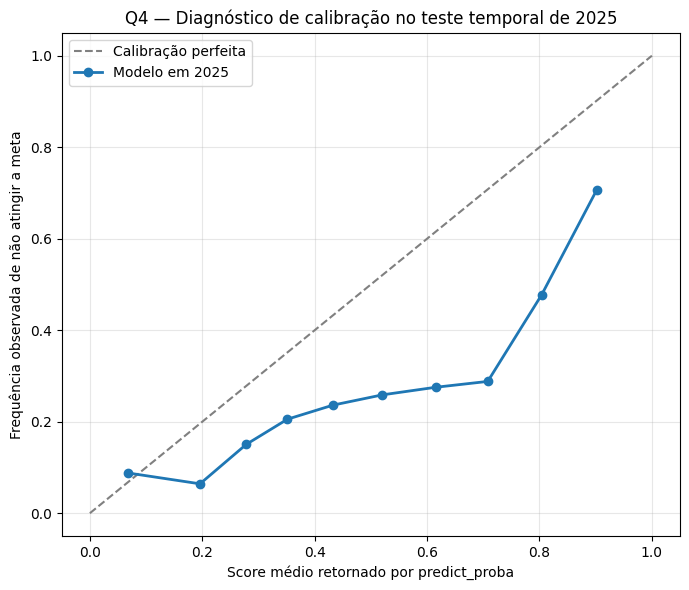

In [85]:
fracao_positivos_q4, score_medio_q4 = calibration_curve(
    y_q4_2025,
    prob_q4_2025,
    n_bins=10,
    strategy='quantile',
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    [0, 1],
    [0, 1],
    '--',
    color='gray',
    label='Calibração perfeita',
)
ax.plot(
    score_medio_q4,
    fracao_positivos_q4,
    marker='o',
    linewidth=2,
    label='Modelo em 2025',
)

ax.set_xlabel('Score médio retornado por predict_proba')
ax.set_ylabel('Frequência observada de não atingir a meta')
ax.set_title('Q4 — Diagnóstico de calibração no teste temporal de 2025')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [86]:
matriz_confusao_2025 = np.array([
    [tn_2025, fp_2025],
    [fn_2025, tp_2025],
])

### Matriz de confusão normalizada em 2025

Agora normalizamos a matriz de confusão por **classe real**. Assim, cada linha soma 100% e a leitura passa a responder diretamente:

- quanto dos municípios que **atingiram/superaram** a meta foi corretamente classificado;
- quanto dos municípios que **não atingiram** a meta foi efetivamente captado;
- qual fração dos alertas decorre de erros para cada classe observada.

**Mensagem de negócio:** destaca diretamente quanto o modelo consegue captar dos municípios que não atingirão a meta e quantos alertas são excessivos.


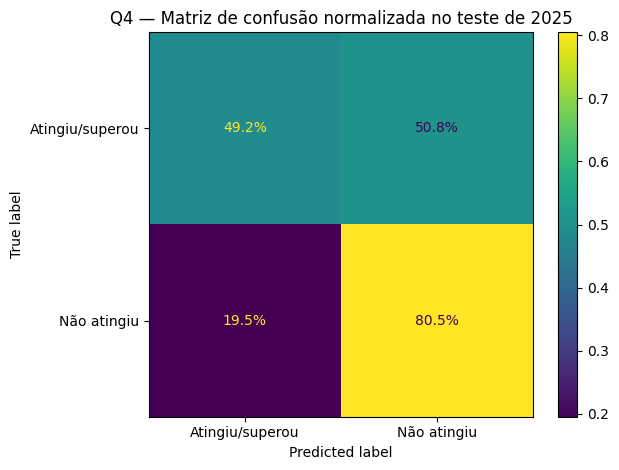

In [87]:
matriz_pct_2025 = confusion_matrix(
    y_q4_2025,
    pred_q4_2025,
    labels=[0, 1],
    normalize='true',
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_pct_2025,
    display_labels=['Atingiu/superou', 'Não atingiu'],
)

disp.plot(values_format='.1%')
plt.title('Q4 — Matriz de confusão normalizada no teste de 2025')
plt.grid(False)
plt.tight_layout()
plt.show()


## 25. Comparação direta — desenvolvimento OOF de 2024 × teste temporal de 2025

Para avaliar a estabilidade temporal, colocamos lado a lado:

- as métricas e contagens obtidas com scores **OOF de desenvolvimento de 2024** no threshold congelado;
- as métricas e contagens do **teste temporal independente de 2025**, produzido pelo modelo ajustado em 100% de 2024.

As métricas OOF de 2024 são úteis para desenvolvimento porque cada registro é previsto por um modelo que não o treinou diretamente. Porém, como esses mesmos scores foram usados para escolher o threshold, elas **não representam uma segunda validação independente do threshold**.

A referência principal de generalização é 2025.

A comparação é exclusivamente diagnóstica. Nenhuma diferença observada em 2025 autoriza alterar modelo, features, preprocessing, `class_weight` ou threshold.

**Mensagem de negócio:** o gráfico comparativo resume rapidamente a estabilidade — ou degradação — do modelo quando avançamos para um período futuro.


Métricas comparativas — desenvolvimento OOF 2024 × teste temporal 2025


,Amostra,PR_AUC,ROC_AUC,Recall,Precision,F1,Balanced_Accuracy,Accuracy,Threshold,Delta_PR_AUC,Delta_ROC_AUC,Delta_Recall,Delta_Precision,Delta_F1,Delta_Balanced_Accuracy,Delta_Accuracy
0,Desenvolvimento OOF 2024,0.673,0.738,0.844,0.576,0.685,0.661,0.645,0.400,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,Teste temporal 2025,0.555,0.737,0.805,0.375,0.512,0.648,0.578,0.400,-0.118,-0.001,-0.040,-0.201,-0.173,-0.013,-0.067


Contagens das matrizes de confusão


,Amostra,TN,FP,FN,TP
0,Desenvolvimento OOF 2024,1407,1541,386,2092
1,Teste temporal 2025,1944,2009,293,1207


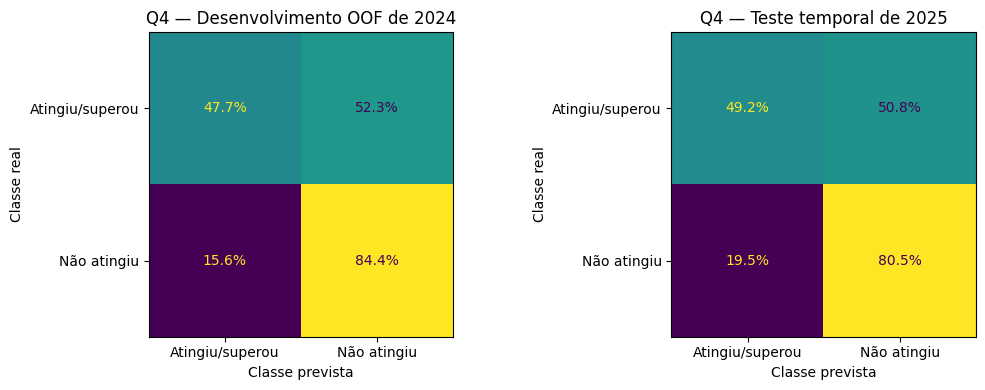

In [88]:
metricas_q4_oof_2024 = pd.Series({

    'PR_AUC': average_precision_score(
        y_q4_2024,
        prob_oof_q4_2024,
    ),

    'ROC_AUC': roc_auc_score(
        y_q4_2024,
        prob_oof_q4_2024,
    ),

    'Recall': recall_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
        zero_division=0,
    ),

    'Precision': precision_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
        zero_division=0,
    ),

    'F1': f1_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
        zero_division=0,
    ),

    'Balanced_Accuracy': balanced_accuracy_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
    ),

    'Accuracy': accuracy_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
    ),

    'Threshold': THRESHOLD_Q4,
})


comparacao_temporal_q4 = pd.DataFrame([

    {
        'Amostra': 'Desenvolvimento OOF 2024',
        **metricas_q4_oof_2024.to_dict(),
    },

    {
        'Amostra': 'Teste temporal 2025',

        **metricas_q4_2025[
            [
                'PR_AUC',
                'ROC_AUC',
                'Recall',
                'Precision',
                'F1',
                'Balanced_Accuracy',
                'Accuracy',
                'Threshold',
            ]
        ].to_dict(),
    },

])


metricas_delta_q4 = [
    'PR_AUC',
    'ROC_AUC',
    'Recall',
    'Precision',
    'F1',
    'Balanced_Accuracy',
    'Accuracy',
]


for metrica in metricas_delta_q4:

    comparacao_temporal_q4[f'Delta_{metrica}'] = (
        comparacao_temporal_q4[metrica]
        - comparacao_temporal_q4.loc[
            comparacao_temporal_q4['Amostra'].eq(
                'Desenvolvimento OOF 2024'
            ),
            metrica,
        ].iloc[0]
    )


print(
    'Métricas comparativas — '
    'desenvolvimento OOF 2024 × teste temporal 2025'
)

display(comparacao_temporal_q4.round(3))


# ---------------------------------------------------------
# Contagens absolutas das matrizes
# ---------------------------------------------------------

comparacao_matrizes_q4 = pd.DataFrame([

    {
        'Amostra': 'Desenvolvimento OOF 2024',
        'TN': int(tn_2024),
        'FP': int(fp_2024),
        'FN': int(fn_2024),
        'TP': int(tp_2024),
    },

    {
        'Amostra': 'Teste temporal 2025',
        'TN': int(tn_2025),
        'FP': int(fp_2025),
        'FN': int(fn_2025),
        'TP': int(tp_2025),
    },

])

print('Contagens das matrizes de confusão')

display(comparacao_matrizes_q4)


# ---------------------------------------------------------
# Matrizes normalizadas por classe real
# Cada linha soma 100%
# ---------------------------------------------------------

matriz_pct_oof_2024 = confusion_matrix(
    y_q4_2024,
    pred_oof_q4_2024_threshold,
    labels=[0, 1],
    normalize='true',
)

matriz_pct_2025 = confusion_matrix(
    y_q4_2025,
    pred_q4_2025,
    labels=[0, 1],
    normalize='true',
)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))


# OOF 2024
ConfusionMatrixDisplay(
    confusion_matrix=matriz_pct_oof_2024,
    display_labels=['Atingiu/superou', 'Não atingiu'],
).plot(
    ax=axes[0],
    values_format='.1%',
    colorbar=False,
)

axes[0].set_title('Q4 — Desenvolvimento OOF de 2024')
axes[0].set_xlabel('Classe prevista')
axes[0].set_ylabel('Classe real')
axes[0].grid(False)


# Teste temporal 2025
ConfusionMatrixDisplay(
    confusion_matrix=matriz_pct_2025,
    display_labels=['Atingiu/superou', 'Não atingiu'],
).plot(
    ax=axes[1],
    values_format='.1%',
    colorbar=False,
)

axes[1].set_title('Q4 — Teste temporal de 2025')
axes[1].set_xlabel('Classe prevista')
axes[1].set_ylabel('Classe real')
axes[1].grid(False)


plt.tight_layout()
plt.show()

### Desempenho: desenvolvimento OOF 2024 versus teste temporal 2025

O gráfico abaixo compara as métricas centrais de desempenho entre o desenvolvimento OOF de 2024 e o teste temporal independente de 2025.

**Mensagem de negócio:** comunica de forma rápida a estabilidade — ou degradação — do modelo em um período futuro.


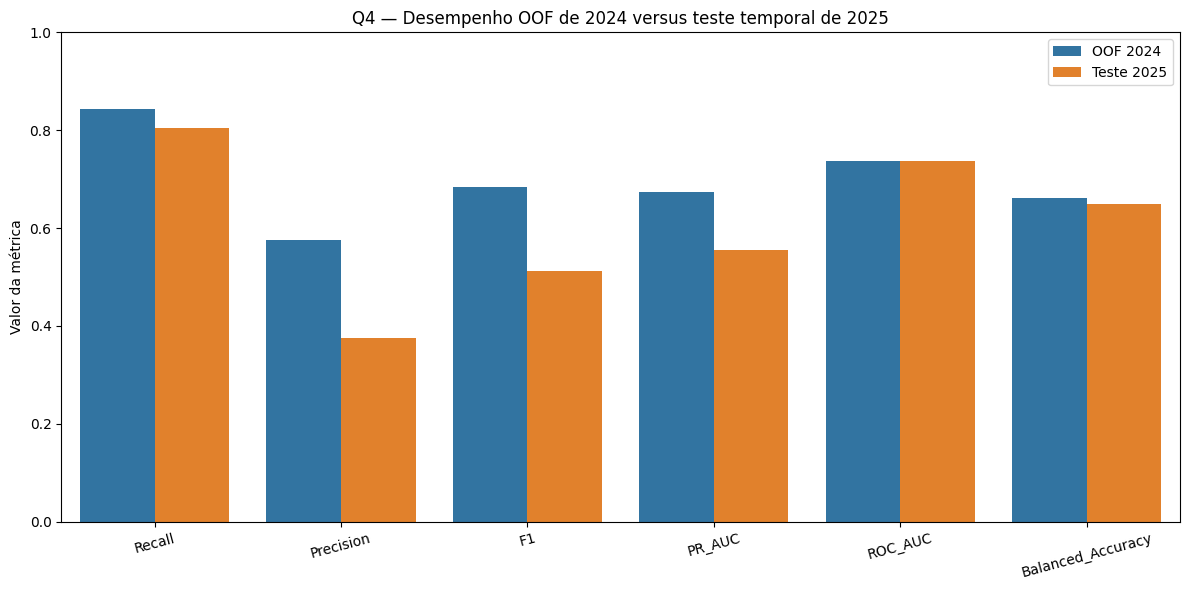

In [89]:
comparacao_plot_q4 = pd.DataFrame([
    {
        'Período': 'OOF 2024',
        **metricas_q4_oof_2024.to_dict(),
    },
    {
        'Período': 'Teste 2025',
        **metricas_q4_2025.to_dict(),
    },
])

metricas_plot_q4 = (
    comparacao_plot_q4
    .melt(
        id_vars='Período',
        value_vars=[
            'Recall',
            'Precision',
            'F1',
            'PR_AUC',
            'ROC_AUC',
            'Balanced_Accuracy',
        ],
        var_name='Métrica',
        value_name='Valor',
    )
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=metricas_plot_q4,
    x='Métrica',
    y='Valor',
    hue='Período',
    ax=ax,
)
ax.set_ylim(0, 1)
ax.set_title('Q4 — Desempenho OOF de 2024 versus teste temporal de 2025')
ax.set_xlabel('')
ax.set_ylabel('Valor da métrica')
ax.legend(title='')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Comparação descritiva das distribuições entre 2024 e 2025

Como complemento à comparação de desempenho, observamos a distribuição de `meta` e `esforco_pactuado` nos dois períodos.

Esse gráfico pode sugerir mudanças na população observada, mas **não constitui sozinho evidência de data drift ou concept drift**.


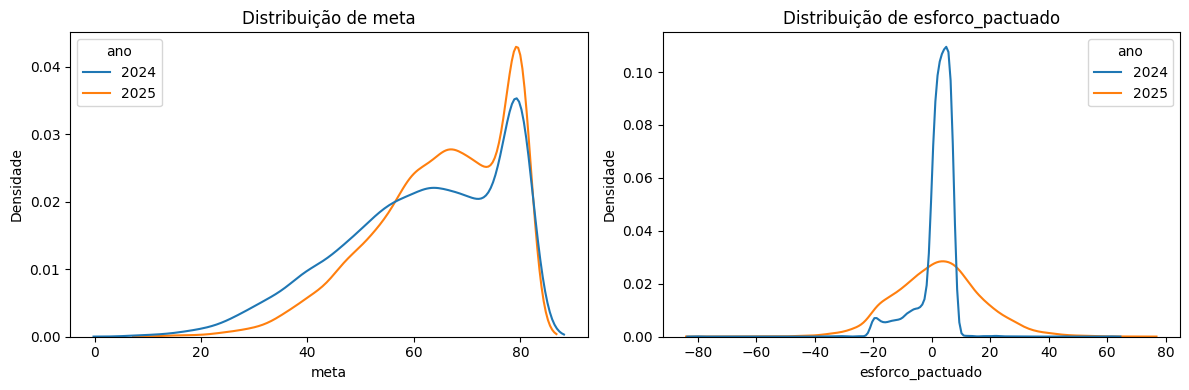

In [90]:
variaveis_distribuicao_temporal_q4 = ['meta', 'esforco_pactuado']

base_distribuicao_temporal_q4 = dados_q4.loc[
    dados_q4['ano'].isin([2024, 2025]),
    ['ano', *variaveis_distribuicao_temporal_q4],
].copy()

base_distribuicao_temporal_q4['ano'] = (
    base_distribuicao_temporal_q4['ano'].astype(str)
)

fig, axes = plt.subplots(
    1,
    len(variaveis_distribuicao_temporal_q4),
    figsize=(12, 4),
)

for ax, variavel in zip(axes, variaveis_distribuicao_temporal_q4):
    sns.kdeplot(
        data=base_distribuicao_temporal_q4,
        x=variavel,
        hue='ano',
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f'Distribuição de {variavel}')
    ax.set_xlabel(variavel)
    ax.set_ylabel('Densidade')

plt.tight_layout()
plt.show()


## 26. Conclusão da validação temporal

A comparação entre desenvolvimento OOF de 2024 e teste temporal de 2025 mostra um resultado mais específico do que uma simples “queda de desempenho”.

### O que permaneceu relativamente estável

A **ROC-AUC permaneceu praticamente inalterada**, indicando que a capacidade global de ordenar municípios de maior e menor risco foi preservada no período futuro.

O **Recall** e a **Balanced Accuracy** também apresentaram redução relativamente pequena. No teste temporal, o modelo continua captando a maior parte dos municípios que efetivamente não atingem a meta.

### O que se deteriorou

A maior perda ocorreu em **Precision, F1 e PR-AUC**.

Essa queda precisa ser interpretada junto com a mudança de prevalência: a proporção de municípios que não atingiram a meta caiu de forma expressiva entre 2024 e 2025. Como Precision e PR-AUC são sensíveis à prevalência da classe positiva, parte da redução é consequência dessa mudança de contexto e não deve ser interpretada isoladamente como colapso da capacidade discriminativa do modelo.

A curva Precision–Recall de 2025 permanece claramente acima da linha de prevalência em grande parte do domínio, mostrando que o modelo ainda oferece **ganho real de priorização em relação a uma seleção aleatória**.

### Consequência operacional do threshold

A matriz de confusão normalizada mostra que o threshold de `0,40` preserva **alta sensibilidade para a classe de risco**, mas também sinaliza como risco uma parcela elevada dos municípios que, ao final, atingem ou superam a meta.

Portanto, o modelo é adequado para uma estratégia de **triagem de alta cobertura**, mas não para uma política em que cada alerta gere uma intervenção cara ou automática. Nesses casos, o ranking por score é mais útil do que a classificação binária isolada.

### Calibração

O diagnóstico de calibração de 2025 mostra desvio relevante em relação à diagonal de calibração perfeita. Em grande parte da faixa, os scores retornados pelo modelo são superiores à frequência observada do evento, indicando **tendência de superestimação do risco**.

Por esse motivo, a saída de `predict_proba` deve continuar sendo tratada como **score de risco para ordenação e priorização**, e não como probabilidade calibrada de não atingir a meta.

### Síntese da validação temporal

O teste de 2025 sustenta que o modelo **generaliza razoavelmente como ferramenta de discriminação e ranking**, mas com perda de eficiência operacional no threshold fixo, principalmente pela queda de Precision e pelo volume de falsos positivos.

A diferença entre os períodos é compatível com mudança de prevalência e com alterações nas distribuições de algumas variáveis, mas esses gráficos, isoladamente, **não comprovam data drift ou concept drift**.

A partir deste ponto:

> **modelo, features, preprocessing, `class_weight` e threshold permanecem congelados.**

As etapas seguintes são exclusivamente de interpretação e aplicação:

> **análise de erros → ranking por score de risco → coeficientes da Regressão Logística → resposta final à Q4**


## 27. Análise de erros no teste temporal

As métricas globais não mostram quais municípios foram classificados corretamente ou incorretamente.

Vamos associar a cada município uma das quatro situações:

- verdadeiro negativo: atingiu a meta e não foi sinalizado;
- falso positivo: atingiu a meta, mas foi sinalizado;
- falso negativo: não atingiu a meta e não foi sinalizado;
- verdadeiro positivo: não atingiu a meta e foi sinalizado.

Nesta etapa, variáveis como `taxa_realizada` podem reaparecer **somente para auditoria do resultado de 2025**.
Elas não são utilizadas como preditores.

In [91]:
avaliacao_q4_2025 = chaves_q4_2025.copy()

# Variáveis de negócio usadas apenas para interpretar os resultados.
for coluna in [
    'meta',
    'taxa_lag1',
    'esforco_pactuado',
    'taxa_realizada',
]:
    if coluna in dados_q4_2025.columns:
        avaliacao_q4_2025[coluna] = dados_q4_2025[coluna]

avaliacao_q4_2025['score_risco_nao_atingir_meta'] = prob_q4_2025
avaliacao_q4_2025['classe_prevista'] = pred_q4_2025
avaliacao_q4_2025['classe_real'] = y_q4_2025.to_numpy()

condicoes_resultado = [
    (
        avaliacao_q4_2025['classe_real'].eq(0)
        & avaliacao_q4_2025['classe_prevista'].eq(0)
    ),
    (
        avaliacao_q4_2025['classe_real'].eq(0)
        & avaliacao_q4_2025['classe_prevista'].eq(1)
    ),
    (
        avaliacao_q4_2025['classe_real'].eq(1)
        & avaliacao_q4_2025['classe_prevista'].eq(0)
    ),
    (
        avaliacao_q4_2025['classe_real'].eq(1)
        & avaliacao_q4_2025['classe_prevista'].eq(1)
    ),
]

rotulos_resultado = [
    'Verdadeiro negativo',
    'Falso positivo',
    'Falso negativo',
    'Verdadeiro positivo',
]

avaliacao_q4_2025['tipo_resultado'] = np.select(
    condicoes_resultado,
    rotulos_resultado,
    default='Revisar',
)

ordem_resultados = [
    'Verdadeiro negativo',
    'Falso positivo',
    'Falso negativo',
    'Verdadeiro positivo',
]

resumo_erros_q4 = (
    avaliacao_q4_2025['tipo_resultado']
    .value_counts()
    .reindex(ordem_resultados, fill_value=0)
    .rename('municipios')
    .to_frame()
)

resumo_erros_q4['percentual'] = (
    resumo_erros_q4['municipios']
    / len(avaliacao_q4_2025)
    * 100
)

display(resumo_erros_q4.round(3))

,municipios,percentual
tipo_resultado,,
Verdadeiro negativo,1944,35.650
Falso positivo,2009,36.842
Falso negativo,293,5.373
Verdadeiro positivo,1207,22.135


### 27.1 Falsos negativos

Os falsos negativos são especialmente importantes para Q4:

> municípios que efetivamente não atingiram a meta, mas não foram sinalizados pelo modelo.

Vamos mostrar os casos com maior **score de risco** dentro desse grupo. Eles são erros que ficaram mais próximos de serem sinalizados pelo threshold de `0,40`.


In [92]:
falsos_negativos_q4 = (
    avaliacao_q4_2025.loc[
        avaliacao_q4_2025['tipo_resultado'].eq('Falso negativo')
    ]
    .sort_values(
        'score_risco_nao_atingir_meta',
        ascending=False,
    )
)

colunas_fn = [
    c for c in [
        'id_municipio',
        'nome_municipio',
        'id_uf',
        'uf',
        'regiao',
        'meta',
        'taxa_lag1',
        'esforco_pactuado',
        'taxa_realizada',
        'score_risco_nao_atingir_meta',
    ]
    if c in falsos_negativos_q4.columns
]

print(f'Total de falsos negativos: {len(falsos_negativos_q4):,}')
display(
    falsos_negativos_q4[colunas_fn]
    .head(20)
    .reset_index(drop=True)
)

Total de falsos negativos: 293


,id_municipio,nome_municipio,id_uf,uf,regiao,meta,taxa_lag1,esforco_pactuado,taxa_realizada,score_risco_nao_atingir_meta
0,3507001,Boituva,35,SP,Sudeste,68.000,69.830,-1.830,67.456,0.399
1,3514809,Eldorado,35,SP,Sudeste,68.000,75.190,-7.190,58.621,0.398
2,3162575,São João do Manteninha,31,MG,Sudeste,80.000,71.700,8.300,74.667,0.397
3,3540002,Pompéia,35,SP,Sudeste,68.000,60.320,7.680,67.021,0.396
4,3525201,Jarinu,35,SP,Sudeste,59.000,44.070,14.930,54.527,0.395
5,3144508,Nazareno,31,MG,Sudeste,80.000,85.360,-5.360,75.490,0.395
6,3524709,Jaguariúna,35,SP,Sudeste,68.000,70.220,-2.220,64.613,0.394
7,3148707,Pedra Azul,31,MG,Sudeste,65.000,60.740,4.260,60.000,0.394
8,2103604,Coroatá,21,MA,Nordeste,54.000,55.720,-1.720,46.233,0.394
9,3140159,Mário Campos,31,MG,Sudeste,73.000,74.090,-1.090,72.826,0.393


### 27.2 Casos próximos ao threshold

Também é útil observar municípios cujo **score de risco** ficou próximo de `0,40`.

Esses casos representam previsões de menor margem e ajudam a entender que o threshold é uma regra operacional, não uma fronteira natural entre dois tipos de município.


In [93]:
avaliacao_q4_2025['distancia_ate_threshold'] = (
    avaliacao_q4_2025['score_risco_nao_atingir_meta']
    - THRESHOLD_Q4
).abs()

casos_proximos_threshold_q4 = (
    avaliacao_q4_2025
    .sort_values('distancia_ate_threshold')
    .head(20)
)

colunas_proximos = [
    c for c in [
        'id_municipio',
        'nome_municipio',
        'id_uf',
        'uf',
        'regiao',
        'meta',
        'esforco_pactuado',
        'score_risco_nao_atingir_meta',
        'classe_prevista',
        'classe_real',
        'tipo_resultado',
    ]
    if c in casos_proximos_threshold_q4.columns
]

display(
    casos_proximos_threshold_q4[colunas_proximos]
    .reset_index(drop=True)
)

,id_municipio,nome_municipio,id_uf,uf,regiao,meta,esforco_pactuado,score_risco_nao_atingir_meta,classe_prevista,classe_real,tipo_resultado
0,3163201,São José do Alegre,31,MG,Sudeste,78.000,-8.260,0.400,0,0,Verdadeiro negativo
1,2919603,Macajuba,29,BA,Nordeste,34.000,3.860,0.400,1,0,Falso positivo
2,3553807,Taquarituba,35,SP,Sudeste,62.000,5.330,0.400,1,1,Verdadeiro positivo
3,1701002,Ananás,17,TO,Norte,53.000,6.310,0.399,0,0,Verdadeiro negativo
4,2606606,Ibimirim,26,PE,Nordeste,60.000,-1.760,0.399,0,0,Verdadeiro negativo
5,3205101,Viana,32,ES,Sudeste,73.000,4.200,0.401,1,0,Falso positivo
6,3510708,Cardoso,35,SP,Sudeste,72.000,12.140,0.401,1,0,Falso positivo
7,3507001,Boituva,35,SP,Sudeste,68.000,-1.830,0.399,0,1,Falso negativo
8,3130606,Inconfidentes,31,MG,Sudeste,80.000,-6.180,0.399,0,0,Verdadeiro negativo
9,5001003,Aparecida do Taboado,50,MS,Centro-Oeste,61.000,3.500,0.401,1,1,Verdadeiro positivo


## 28. Ranking por score de risco

Para aplicação de negócio, o score contínuo do modelo é mais informativo do que apenas a classe 0/1.

Ordenaremos os municípios de 2025 por:

```python
score_risco_nao_atingir_meta
```

em ordem decrescente.

O target real de 2025 aparece apenas para auditoria do teste temporal.

> O score é um instrumento de **priorização e ordenação de risco**. Sem evidência de calibração, ele não deve ser lido como probabilidade calibrada de descumprimento.


In [94]:
ranking_q4_2025 = (
    avaliacao_q4_2025
    .sort_values(
        'score_risco_nao_atingir_meta',
        ascending=False,
    )
    .reset_index(drop=True)
)

ranking_q4_2025.insert(
    0,
    'posicao_risco',
    np.arange(1, len(ranking_q4_2025) + 1),
)

colunas_ranking = [
    c for c in [
        'posicao_risco',
        'id_municipio',
        'nome_municipio',
        'id_uf',
        'uf',
        'regiao',
        'meta',
        'taxa_lag1',
        'esforco_pactuado',
        'score_risco_nao_atingir_meta',
        'classe_prevista',
        'classe_real',
        'tipo_resultado',
    ]
    if c in ranking_q4_2025.columns
]

print('Top 20 municípios por score de risco de não atingir a meta:')
display(
    ranking_q4_2025[colunas_ranking]
    .head(20)
)
n_top_q4 = min(20, len(ranking_q4_2025))
top_q4 = ranking_q4_2025.head(n_top_q4)
n_positivos_top_q4 = int(top_q4['classe_real'].eq(1).sum())
pct_positivos_top_q4 = (
    n_positivos_top_q4 / n_top_q4 * 100
    if n_top_q4 else np.nan
)

print(
    f'Entre os Top {n_top_q4} por score, '
    f'{n_positivos_top_q4} não atingiram a meta '
    f'({pct_positivos_top_q4:.1f}%).'
)


Top 20 municípios por score de risco de não atingir a meta:


,posicao_risco,id_municipio,nome_municipio,id_uf,uf,regiao,meta,taxa_lag1,esforco_pactuado,score_risco_nao_atingir_meta,classe_prevista,classe_real,tipo_resultado
0,1,4301073,Arroio do Padre,43,RS,Sul,80.000,18.200,61.800,0.981,1,1,Verdadeiro positivo
1,2,1303304,Novo Aripuanã,13,AM,Norte,80.000,50.990,29.010,0.979,1,1,Verdadeiro positivo
2,3,2411106,Ruy Barbosa,24,RN,Nordeste,65.000,35.000,30.000,0.978,1,0,Falso positivo
3,4,4320354,Sentinela do Sul,43,RS,Sul,76.000,23.500,52.500,0.976,1,1,Verdadeiro positivo
4,5,1504307,Maracanã,15,PA,Norte,72.000,47.510,24.490,0.976,1,1,Verdadeiro positivo
5,6,2411502,Santo Antônio,24,RN,Nordeste,71.000,23.560,47.440,0.975,1,1,Verdadeiro positivo
6,7,4311122,Jaquirana,43,RS,Sul,72.000,25.600,46.400,0.972,1,1,Verdadeiro positivo
7,8,1301654,Guajará,13,AM,Norte,68.000,54.660,13.340,0.972,1,1,Verdadeiro positivo
8,9,4313953,Pantano Grande,43,RS,Sul,75.000,25.700,49.300,0.972,1,1,Verdadeiro positivo
9,10,4304408,Canela,43,RS,Sul,79.000,42.200,36.800,0.972,1,1,Verdadeiro positivo


Entre os Top 20 por score, 16 não atingiram a meta (80.0%).


## 29. Interpretação da Regressão Logística — coeficientes

Como todas as features da Regressão Logística foram padronizadas com `StandardScaler`, os coeficientes podem
ser comparados em uma escala comum.

A leitura será:

- coeficiente **positivo** → associado a aumento do escore de risco;
- coeficiente **negativo** → associado a redução do escore de risco;
- maior valor absoluto → maior peso na decisão linear do modelo.

Essa interpretação é **preditiva**, não causal.

Não devemos escrever que uma variável causa o não cumprimento da meta. O correto é dizer que ela está
associada a maior ou menor risco estimado pelo modelo.

In [95]:
preprocessador_final_q4 = modelo_q4_final.named_steps['preprocessador']
modelo_logistico_final_q4 = modelo_q4_final.named_steps['modelo']

nomes_features_transformadas = (
    preprocessador_final_q4
    .get_feature_names_out()
)

# O ColumnTransformer adiciona o prefixo "num__".
nomes_features_limpas = [
    nome.replace('num__', '', 1)
    for nome in nomes_features_transformadas
]

coeficientes_q4 = modelo_logistico_final_q4.coef_.ravel()

assert len(nomes_features_limpas) == len(coeficientes_q4)

tabela_coeficientes_q4 = pd.DataFrame({
    'feature': nomes_features_limpas,
    'coeficiente': coeficientes_q4,
})

tabela_coeficientes_q4['coeficiente_abs'] = (
    tabela_coeficientes_q4['coeficiente'].abs()
)

tabela_coeficientes_q4['direcao'] = np.where(
    tabela_coeficientes_q4['coeficiente'] > 0,
    'Aumenta o risco estimado',
    'Reduz o risco estimado',
)

tabela_coeficientes_q4 = (
    tabela_coeficientes_q4
    .sort_values(
        'coeficiente_abs',
        ascending=False,
    )
    .reset_index(drop=True)
)

print('Principais coeficientes em valor absoluto:')
display(
    tabela_coeficientes_q4
    .head(20)
    .round(4)
)

Principais coeficientes em valor absoluto:


,feature,coeficiente,coeficiente_abs,direcao
0,meta,1.406,1.406,Aumenta o risco estimado
1,ctx_inep_uf_media_portugues_lag1,-0.838,0.838,Reduz o risco estimado
2,proficiencia_lag1,-0.648,0.648,Reduz o risco estimado
3,ctx_atu_fundamental_anos_iniciais,0.436,0.436,Aumenta o risco estimado
4,ctx_atlas_taxa_analfabetismo_11a14,0.355,0.355,Aumenta o risco estimado
5,ctx_inep_uf_percentual_participacao_lag1,-0.253,0.253,Reduz o risco estimado
6,participacao_lag1,-0.234,0.234,Reduz o risco estimado
7,ctx_atlas_taxa_analfabetismo_15a17,-0.194,0.194,Reduz o risco estimado
8,ctx_atlas_taxa_densidade_domiciliar,0.170,0.170,Aumenta o risco estimado
9,ctx_atu_fundamental_1_ano,-0.153,0.153,Reduz o risco estimado


In [96]:
print('Top 10 coeficientes positivos — associados a maior risco estimado:')
display(
    tabela_coeficientes_q4
    .sort_values('coeficiente', ascending=False)
    .head(10)[
        ['feature', 'coeficiente', 'direcao']
    ]
    .round(4)
)

print('\nTop 10 coeficientes negativos — associados a menor risco estimado:')
display(
    tabela_coeficientes_q4
    .sort_values('coeficiente', ascending=True)
    .head(10)[
        ['feature', 'coeficiente', 'direcao']
    ]
    .round(4)
)

Top 10 coeficientes positivos — associados a maior risco estimado:


,feature,coeficiente,direcao
0,meta,1.406,Aumenta o risco estimado
3,ctx_atu_fundamental_anos_iniciais,0.436,Aumenta o risco estimado
4,ctx_atlas_taxa_analfabetismo_11a14,0.355,Aumenta o risco estimado
8,ctx_atlas_taxa_densidade_domiciliar,0.170,Aumenta o risco estimado
11,ctx_atlas_taxa_fora_escola_4a5,0.150,Aumenta o risco estimado
16,ctx_atlas_taxa_maes_chefes_familia,0.086,Aumenta o risco estimado
18,ctx_fundeb_nse_uf,0.078,Aumenta o risco estimado
19,ctx_atlas_taxa_frequencia_0a3,0.074,Aumenta o risco estimado
21,ctx_atlas_indice_gini,0.064,Aumenta o risco estimado
25,ctx_atu_creche,0.038,Aumenta o risco estimado



Top 10 coeficientes negativos — associados a menor risco estimado:


,feature,coeficiente,direcao
1,ctx_inep_uf_media_portugues_lag1,-0.838,Reduz o risco estimado
2,proficiencia_lag1,-0.648,Reduz o risco estimado
5,ctx_inep_uf_percentual_participacao_lag1,-0.253,Reduz o risco estimado
6,participacao_lag1,-0.234,Reduz o risco estimado
7,ctx_atlas_taxa_analfabetismo_15a17,-0.194,Reduz o risco estimado
9,ctx_atu_fundamental_1_ano,-0.153,Reduz o risco estimado
10,ctx_atlas_taxa_fora_escola_6a14,-0.153,Reduz o risco estimado
12,ctx_atu_fundamental_4_ano,-0.147,Reduz o risco estimado
13,ctx_atu_fundamental_5_ano,-0.138,Reduz o risco estimado
14,ctx_atlas_taxa_analfabetismo_15mais,-0.117,Reduz o risco estimado


### Visualização dos principais coeficientes da Regressão Logística

O gráfico reúne os coeficientes mais negativos e mais positivos do modelo já ajustado.

Como as features foram padronizadas, a magnitude dos coeficientes é comparável na escala do modelo:

- valores positivos estão associados a maior score de risco;
- valores negativos estão associados a menor score de risco.

A interpretação continua sendo **preditiva, não causal**.


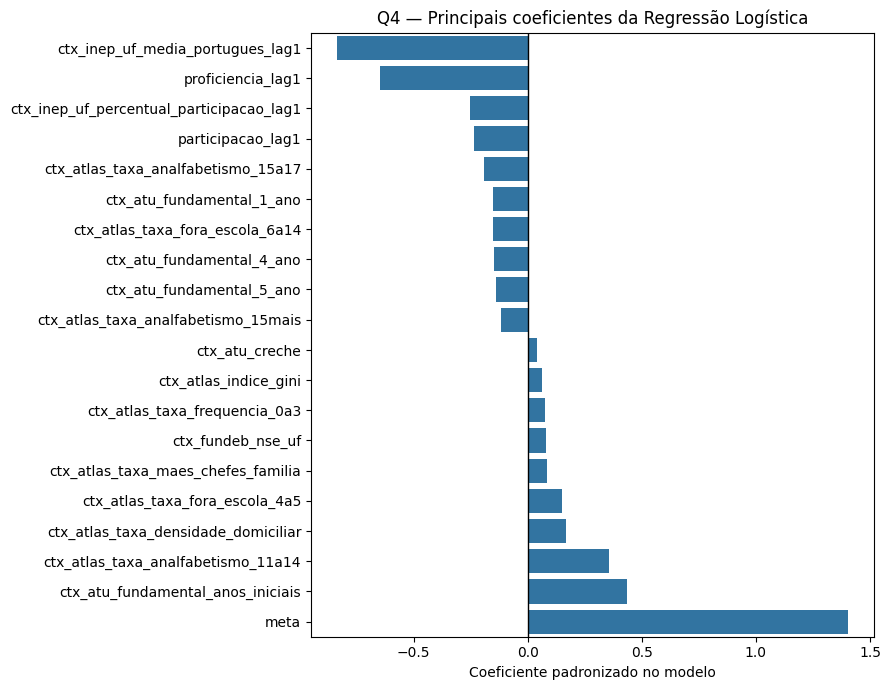

In [97]:
top_coef_q4 = pd.concat([
    tabela_coeficientes_q4.nsmallest(10, 'coeficiente'),
    tabela_coeficientes_q4.nlargest(10, 'coeficiente'),
]).drop_duplicates().sort_values('coeficiente')

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=top_coef_q4,
    x='coeficiente',
    y='feature',
    ax=ax,
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Q4 — Principais coeficientes da Regressão Logística')
ax.set_xlabel('Coeficiente padronizado no modelo')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 30. Conclusão final — resposta à Q4

> **Q4 — Como prever municípios que podem não atingir metas futuras?**

A solução construída permite **ordenar e sinalizar municípios para acompanhamento preventivo**, usando uma Regressão Logística desenvolvida exclusivamente com dados de 2024 e avaliada temporalmente em 2025.

A configuração final permanece:

- **modelo:** Regressão Logística;
- **features:** conjunto final auditado em `FEATURES_Q4`;
- **preprocessing:** imputação pela mediana e padronização;
- **class_weight:** `balanced`;
- **threshold operacional:** `0,40`;
- **métrica preditiva principal:** PR-AUC;
- **métrica operacional prioritária:** Recall.

### Resposta preditiva

O teste temporal mostra que a capacidade de **discriminação e ordenação** do modelo se mantém de forma razoavelmente estável: a ROC-AUC praticamente não se altera entre o desenvolvimento OOF de 2024 e 2025.

Por outro lado, a redução da prevalência da classe positiva em 2025 vem acompanhada de queda de Precision, F1 e PR-AUC. Portanto, o desempenho futuro não deve ser resumido apenas por uma única métrica.

A leitura mais adequada é:

> **o modelo continua útil para priorizar municípios de maior risco, mas o threshold de alta cobertura gera quantidade relevante de falsos positivos.**

### Uso operacional

O threshold `0,40` foi escolhido para favorecer Recall. Isso é coerente quando o custo de deixar um município vulnerável sem sinalização é maior do que o custo de investigar um alerta adicional.

A classificação binária, entretanto, não deve ser usada como decisão automática. Para priorização de recursos, o **ranking pelo score de risco** é mais informativo.

O próprio ranking de 2025 mostra concentração relevante de municípios que de fato não atingiram a meta entre as primeiras posições, reforçando a utilidade do score para triagem.

### Calibração do score

A curva de calibração mostra que os valores produzidos por `predict_proba` **não acompanham adequadamente a frequência observada do evento** e tendem a superestimar o risco em boa parte da faixa.

Assim, esses valores devem ser interpretados como **scores de risco relativos**, úteis para ordenar municípios, e não como probabilidades calibradas de descumprimento.

### Interpretação das variáveis

Os coeficientes reforçam uma estrutura preditiva coerente com o problema:

- `meta` aparece como a associação positiva mais forte: metas mais elevadas tornam o não atingimento mais provável, mantidas as demais variáveis constantes;
- indicadores de desempenho educacional anterior, como proficiência e desempenho médio da UF, aparecem entre as associações negativas mais fortes;
- outras variáveis educacionais e contextuais contribuem adicionalmente para o score.

Essas relações são **associações preditivas condicionais**, não evidências causais.

### Síntese da resposta à Q4

> **A Regressão Logística consegue identificar e ordenar municípios com maior risco de não atingir metas futuras, preservando boa capacidade de discriminação no teste temporal de 2025. Seu melhor uso é como ferramenta de triagem e priorização por score, com threshold de alta cobertura quando a prioridade é Recall. O score não deve ser tratado como probabilidade calibrada, e o volume de falsos positivos precisa ser considerado na capacidade operacional da política pública.**
